<a href="https://colab.research.google.com/github/mitrasouvik1111-spec/fx-gedmd-koopman/blob/main/nifty_short_selling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install yfinance pandas numpy matplotlib seaborn

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Yahoo Finance tickers ──────────────────────────────────────────
TICKERS = {
    "nifty50"  : "^NSEI",
    "banknifty": "^NSEBANK",
    "finnifty" : "NIFTY_FIN_SERVICE.NS",
    "indiavix" : "^INDIAVIX"
}

START = "2018-01-01"
END   = "2025-03-01"

# ── Download ───────────────────────────────────────────────────────
raw = {}
for name, ticker in TICKERS.items():
    df = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
    series = df["Close"]
    series.name = name # Correctly set the name of the Series
    raw[name] = series
    print(f"✅ {name:12s} | {len(df)} rows | {df.index[0].date()} → {df.index[-1].date()}")

# ── Combine into one DataFrame ─────────────────────────────────────
prices = pd.concat(raw.values(), axis=1)
prices.dropna(inplace=True)

print(f"\nCombined shape: {prices.shape}")
print(prices.tail(3))

✅ nifty50      | 1766 rows | 2018-01-02 → 2025-02-28
✅ banknifty    | 1767 rows | 2018-01-01 → 2025-02-28
✅ finnifty     | 1753 rows | 2018-01-01 → 2025-02-28
✅ indiavix     | 1752 rows | 2018-01-01 → 2025-02-28

Combined shape: (1750, 4)
Ticker             ^NSEI      ^NSEBANK  NIFTY_FIN_SERVICE.NS  ^INDIAVIX
Date                                                                   
2025-02-25  22547.550781  48608.351562          23036.050781      13.72
2025-02-27  22545.050781  48743.800781          23173.650391      13.31
2025-02-28  22124.699219  48344.699219          23028.949219      13.91


In [5]:
# Log returns — standard input for HMM and regime models
returns = np.log(prices / prices.shift(1)).dropna()
returns.columns = [c + "_ret" for c in prices.columns]

print(returns.describe().round(4))

       ^NSEI_ret  ^NSEBANK_ret  NIFTY_FIN_SERVICE.NS_ret  ^INDIAVIX_ret
count  1749.0000     1749.0000                 1749.0000      1749.0000
mean      0.0004        0.0004                    0.0005         0.0000
std       0.0112        0.0151                    0.0145         0.0527
min      -0.1390       -0.1831                   -0.1736        -0.3531
25%      -0.0046       -0.0063                   -0.0057        -0.0283
50%       0.0009        0.0008                    0.0009        -0.0032
75%       0.0064        0.0073                    0.0072         0.0243
max       0.0840        0.1000                    0.0891         0.3524


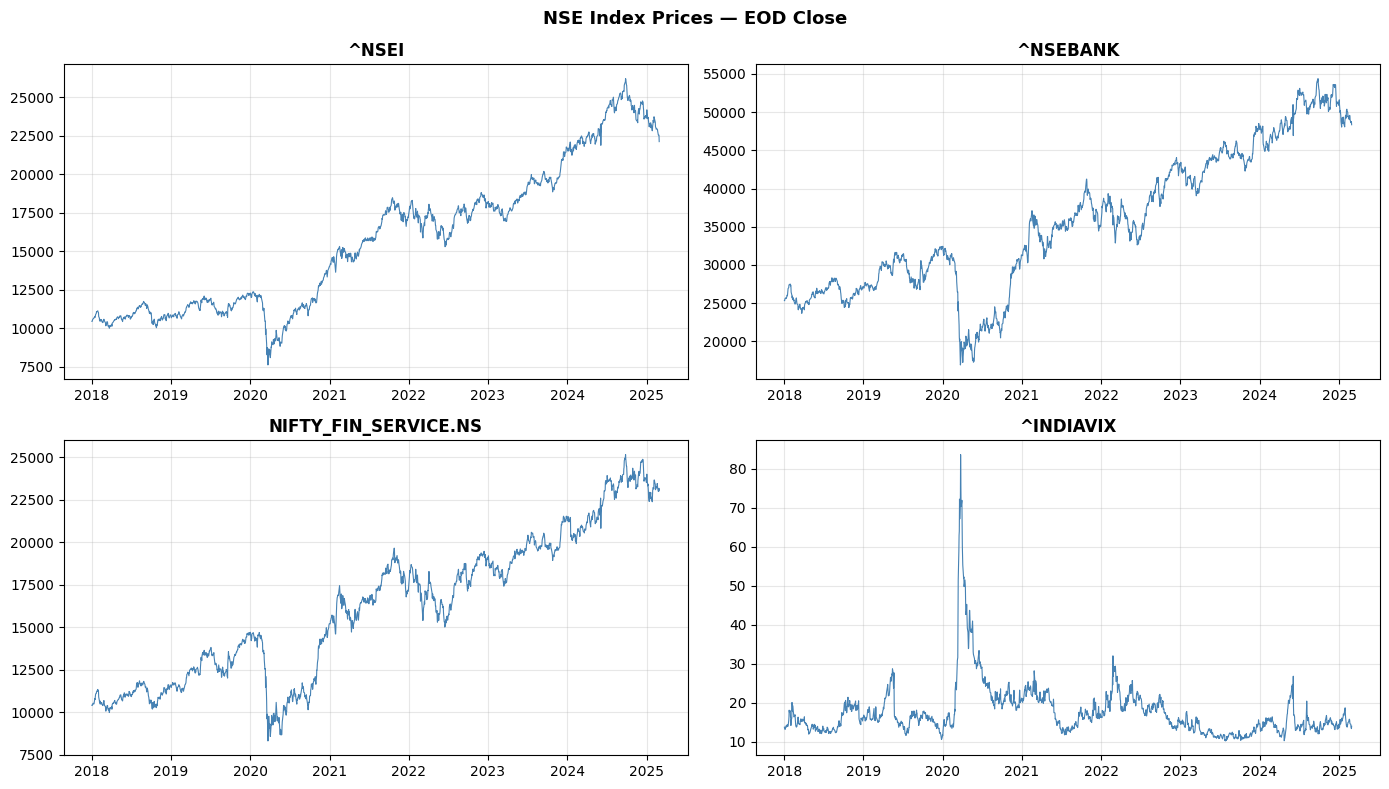

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(prices.columns):
    axes[i].plot(prices.index, prices[col], linewidth=0.8, color="steelblue")
    axes[i].set_title(col.upper(), fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].grid(alpha=0.3)

plt.suptitle("NSE Index Prices — EOD Close", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
# ── Parameters ─────────────────────────────────────────────────────
VOL_SHORT  = 5    # days  (1 week)
VOL_LONG   = 21   # days  (1 month)
MOM_SHORT  = 5
MOM_LONG   = 21

# ── Work on Nifty 50 as primary index ──────────────────────────────
# We'll later extend to BankNifty and FinNifty the same way

nifty_ret = returns["^NSEI_ret"]
vix       = prices["^INDIAVIX"]

features = pd.DataFrame(index=returns.index)

# 1. Realised volatility (annualised)
features["vol_short"] = (
    nifty_ret.rolling(VOL_SHORT).std() * np.sqrt(252)
)
features["vol_long"] = (
    nifty_ret.rolling(VOL_LONG).std() * np.sqrt(252)
)

# 2. Vol ratio — >1 means short-term vol spiking vs long-term
features["vol_ratio"] = features["vol_short"] / features["vol_long"]

# 3. Momentum — cumulative return over window
features["mom_short"] = nifty_ret.rolling(MOM_SHORT).sum()
features["mom_long"]  = nifty_ret.rolling(MOM_LONG).sum()

# 4. VIX features
features["vix_level"]  = vix
features["vix_change"] = vix.pct_change()

# 5. IV premium ratio — VIX (implied) / realised vol
#    >1 = options expensive (good to sell), <1 = options cheap
features["iv_premium"] = (vix / 100) / features["vol_long"]

# ── Drop NaNs from rolling windows ─────────────────────────────────
features.dropna(inplace=True)

print(f"Feature matrix shape: {features.shape}")
print(f"Date range: {features.index[0].date()} → {features.index[-1].date()}")
print("\n", features.describe().round(4))

Feature matrix shape: (1729, 8)
Date range: 2018-02-01 → 2025-02-28

        vol_short   vol_long  vol_ratio  mom_short   mom_long  vix_level  \
count  1729.0000  1729.0000  1729.0000  1729.0000  1729.0000  1729.0000   
mean      0.1392     0.1505     0.9330     0.0021     0.0092    17.5611   
std       0.1138     0.0958     0.3557     0.0247     0.0544     7.1482   
min       0.0169     0.0506     0.0762    -0.2110    -0.4658    10.1400   
25%       0.0797     0.1003     0.6844    -0.0098    -0.0147    13.5600   
50%       0.1126     0.1269     0.9119     0.0038     0.0126    15.7500   
75%       0.1601     0.1666     1.1541     0.0158     0.0402    19.6800   
max       1.3360     0.8946     2.1032     0.1000     0.1986    83.6100   

       vix_change  iv_premium  
count   1729.0000   1729.0000  
mean       0.0013      1.2753  
std        0.0539      0.3225  
min       -0.2975      0.4391  
25%       -0.0280      1.0534  
50%       -0.0032      1.2529  
75%        0.0246      1.4591 

In [10]:
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled = pd.DataFrame(X_scaled, index=features.index, columns=features.columns)

print("Scaled feature stats (should be ~0 mean, ~1 std):")
print(X_scaled.describe().round(3))

Scaled feature stats (should be ~0 mean, ~1 std):
       vol_short  vol_long  vol_ratio  mom_short  mom_long  vix_level  \
count   1729.000  1729.000   1729.000   1729.000  1729.000   1729.000   
mean       0.000     0.000     -0.000      0.000     0.000      0.000   
std        1.000     1.000      1.000      1.000     1.000      1.000   
min       -1.075    -1.043     -2.410     -8.624    -8.742     -1.038   
25%       -0.522    -0.524     -0.699     -0.480    -0.440     -0.560   
50%       -0.233    -0.246     -0.059      0.073     0.062     -0.253   
75%        0.184     0.168      0.622      0.557     0.570      0.297   
max       10.521     7.772      3.291      3.966     3.485      9.243   

       vix_change  iv_premium  
count    1729.000    1729.000  
mean       -0.000       0.000  
std         1.000       1.000  
min        -5.545      -2.594  
25%        -0.544      -0.688  
50%        -0.084      -0.069  
75%         0.431       0.570  
max         7.815       4.792  


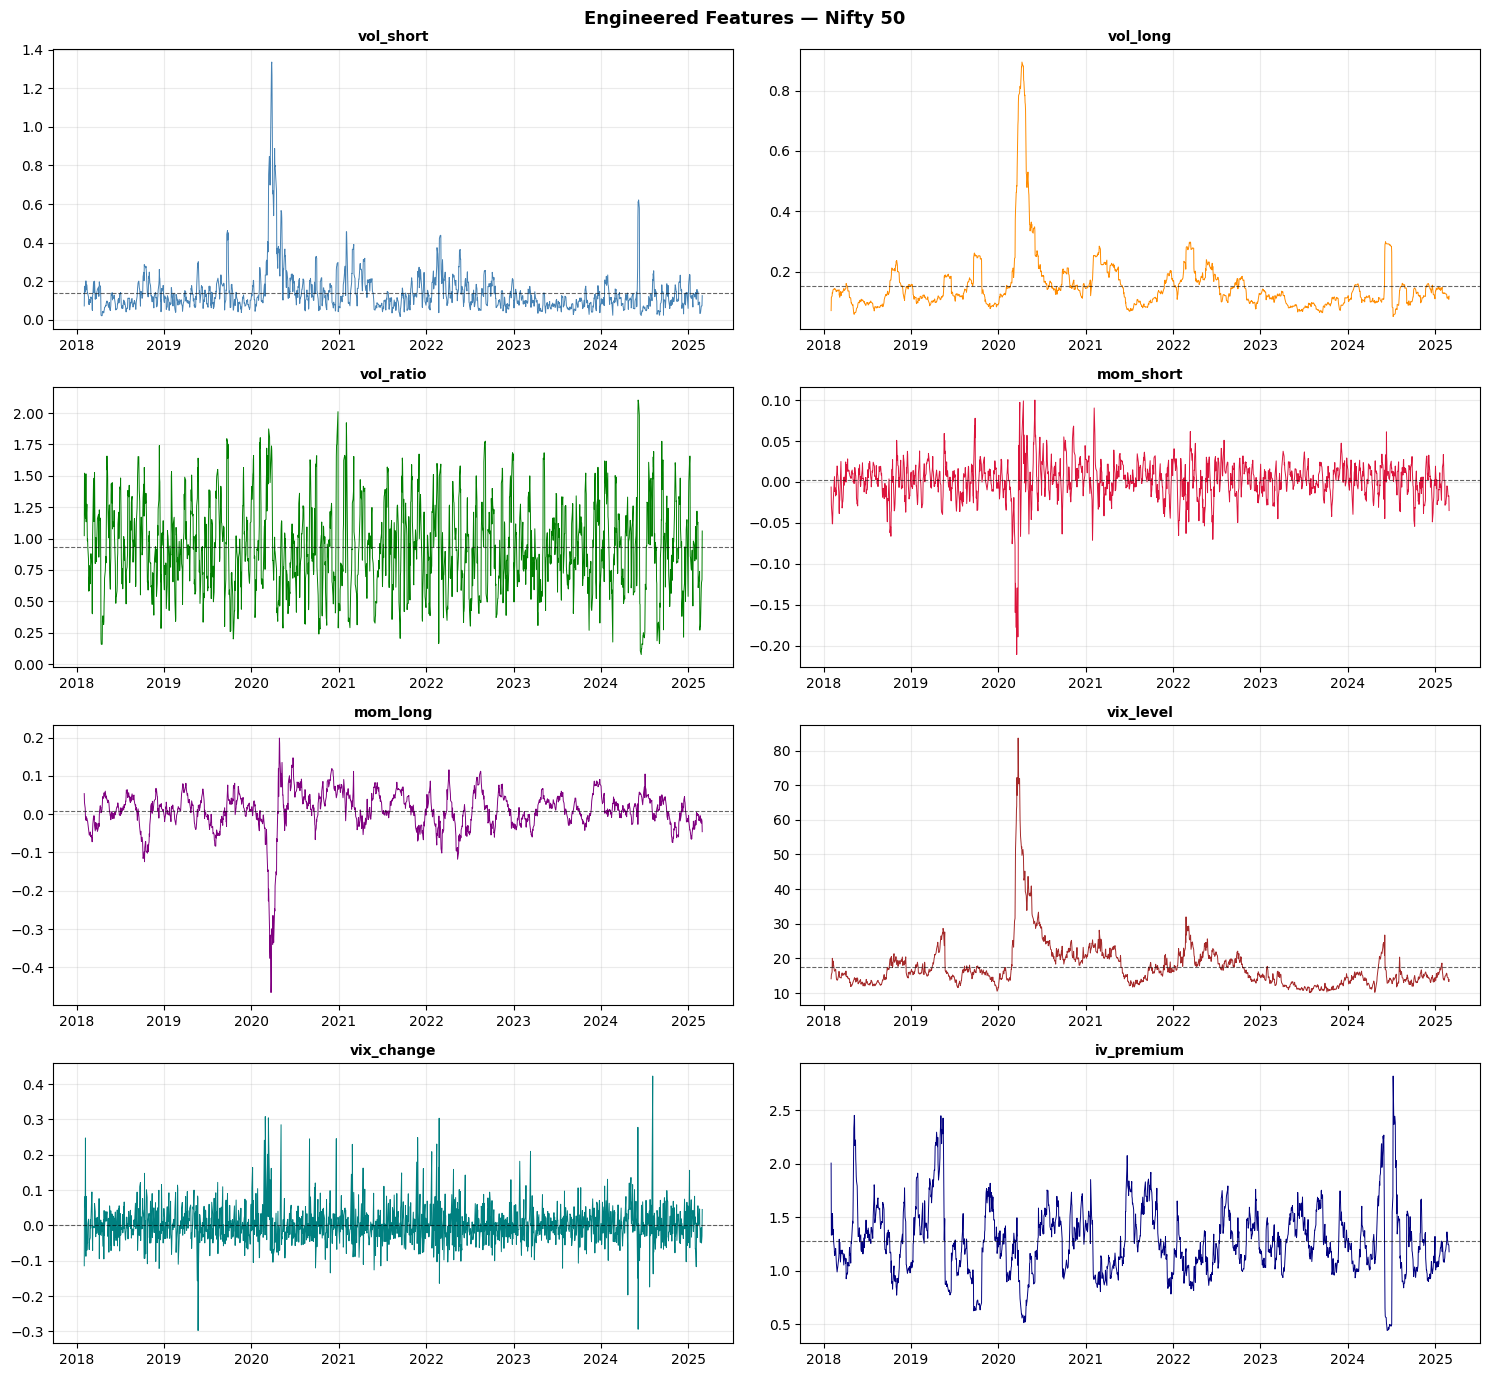

In [11]:
fig, axes = plt.subplots(4, 2, figsize=(15, 14))
axes = axes.flatten()

colors = ["steelblue", "darkorange", "green", "crimson",
          "purple", "brown", "teal", "navy"]

for i, col in enumerate(features.columns):
    axes[i].plot(features.index, features[col],
                 linewidth=0.7, color=colors[i])
    axes[i].set_title(col, fontweight="bold", fontsize=10)
    axes[i].axhline(features[col].mean(), color="black",
                    linestyle="--", linewidth=0.8, alpha=0.6)
    axes[i].grid(alpha=0.25)

plt.suptitle("Engineered Features — Nifty 50", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

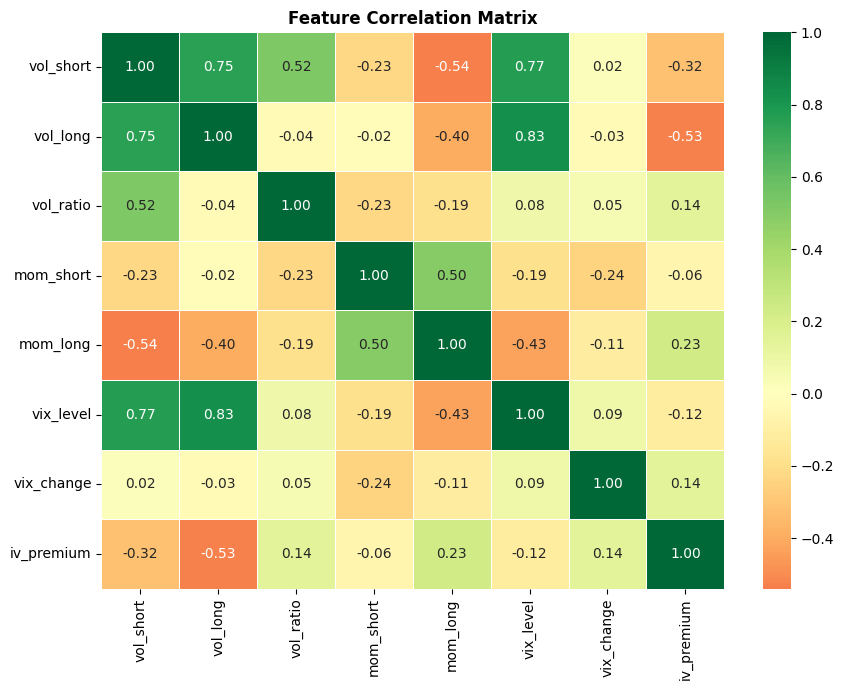

In [12]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    features.corr().round(2),
    annot=True, fmt=".2f",
    cmap="RdYlGn", center=0,
    linewidths=0.5, ax=ax
)
ax.set_title("Feature Correlation Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

In [13]:
pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.2 MB/s eta 0:00:00


In [14]:
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# ── Select features for HMM ────────────────────────────────────────
# We drop vol_short (redundant with vol_ratio + vol_long)
# and keep vix_level over vol_long as it's more regime-informative

HMM_FEATURES = [
    "vol_long",
    "vol_ratio",
    "mom_short",
    "mom_long",
    "vix_level",
    "vix_change",
    "iv_premium"
]

X = features[HMM_FEATURES].copy()

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Fit 3-state HMM ────────────────────────────────────────────────
# n_components=3 → Low vol / High vol / Crisis
# covariance_type="full" → each state has its own covariance matrix
# n_iter=2000 → enough EM iterations to converge

N_STATES = 3

model = GaussianHMM(
    n_components   = N_STATES,
    covariance_type= "full",
    n_iter         = 2000,
    random_state   = 42
)

model.fit(X_scaled)

print(f"Model converged: {model.monitor_.converged}")
print(f"Log-likelihood : {model.score(X_scaled):.2f}")

Model converged: True
Log-likelihood : -9563.09


In [15]:
# Viterbi decode — most likely state sequence
regimes = model.predict(X_scaled)
regime_probs = model.predict_proba(X_scaled)

# Attach back to original index
regime_series = pd.Series(regimes, index=features.index, name="regime")

# ── Label regimes by VIX level (median per state) ─────────────────
vix_by_state = {}
for s in range(N_STATES):
    mask = regime_series == s
    vix_by_state[s] = features.loc[mask, "vix_level"].median()
    print(f"State {s} | median VIX: {vix_by_state[s]:.1f} | "
          f"count: {mask.sum()} days ({mask.mean()*100:.1f}%)")

# Sort states: 0=Low vol, 1=High vol, 2=Crisis
sorted_states = sorted(vix_by_state, key=vix_by_state.get)
state_map = {sorted_states[0]: 0,   # Low vol  → regime 0
             sorted_states[1]: 1,   # High vol → regime 1
             sorted_states[2]: 2}   # Crisis   → regime 2

regime_series = regime_series.map(state_map)
REGIME_LABELS = {0: "Low Vol", 1: "High Vol", 2: "Crisis"}
REGIME_COLORS = {0: "green",   1: "orange",   2: "red"}

print("\nAfter relabelling:")
for r, label in REGIME_LABELS.items():
    count = (regime_series == r).sum()
    print(f"  Regime {r} ({label:8s}): {count} days ({count/len(regime_series)*100:.1f}%)")

State 0 | median VIX: 14.4 | count: 909 days (52.6%)
State 1 | median VIX: 38.4 | count: 71 days (4.1%)
State 2 | median VIX: 19.3 | count: 749 days (43.3%)

After relabelling:
  Regime 0 (Low Vol ): 909 days (52.6%)
  Regime 1 (High Vol): 749 days (43.3%)
  Regime 2 (Crisis  ): 71 days (4.1%)


In [16]:
# How likely is each regime to persist vs switch?
trans_df = pd.DataFrame(
    model.transmat_[sorted_states][:, sorted_states],
    index  =[REGIME_LABELS[i] for i in range(N_STATES)],
    columns=[REGIME_LABELS[i] for i in range(N_STATES)]
).round(3)

print("\nTransition Matrix (row → col):")
print(trans_df)
# High diagonal = regime is sticky (persistent)
# Low diagonal  = regime switches quickly


Transition Matrix (row → col):
          Low Vol  High Vol  Crisis
Low Vol     0.969     0.028   0.003
High Vol    0.038     0.957   0.005
Crisis      0.000     0.090   0.910


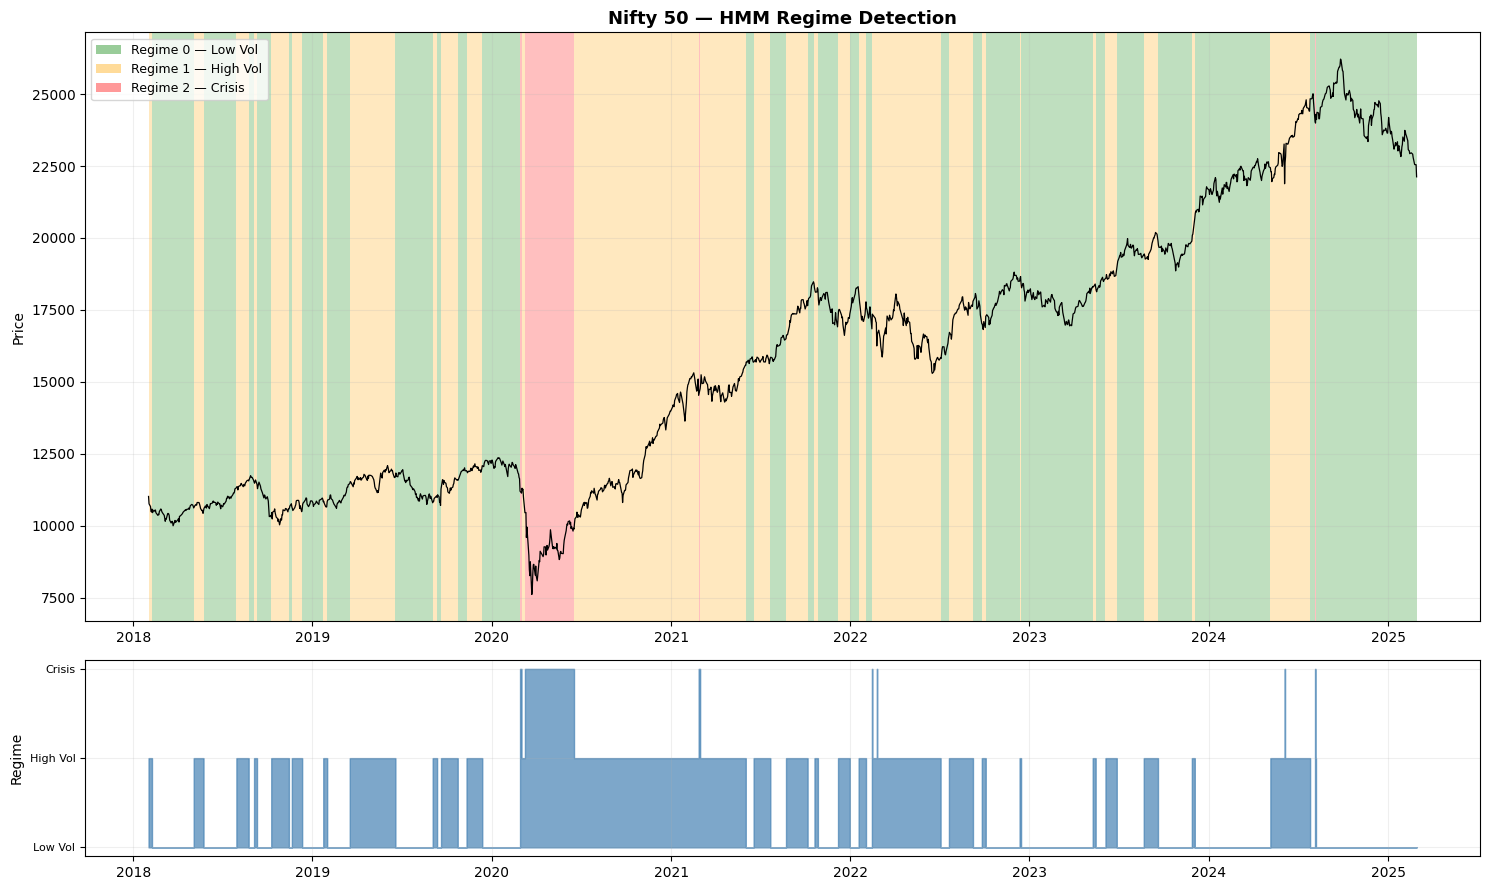

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9),
                                 gridspec_kw={"height_ratios": [3, 1]})

# ── Top: Price with regime background ─────────────────────────────
nifty_price = prices["^NSEI"].loc[regime_series.index]
ax1.plot(nifty_price.index, nifty_price.values,
         color="black", linewidth=0.9, zorder=3)

# Shade background by regime
for regime_id, color in REGIME_COLORS.items():
    mask = regime_series == regime_id
    # Find contiguous blocks
    in_regime = False
    start = None
    for date, val in mask.items():
        if val and not in_regime:
            start = date
            in_regime = True
        elif not val and in_regime:
            ax1.axvspan(start, date, alpha=0.25, color=color, lw=0)
            in_regime = False
    if in_regime:
        ax1.axvspan(start, mask.index[-1], alpha=0.25, color=color, lw=0)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="green",  alpha=0.4, label="Regime 0 — Low Vol"),
    Patch(facecolor="orange", alpha=0.4, label="Regime 1 — High Vol"),
    Patch(facecolor="red",    alpha=0.4, label="Regime 2 — Crisis"),
]
ax1.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax1.set_title("Nifty 50 — HMM Regime Detection", fontweight="bold", fontsize=13)
ax1.set_ylabel("Price")
ax1.grid(alpha=0.2)

# ── Bottom: Regime state over time ────────────────────────────────
ax2.fill_between(regime_series.index, regime_series.values,
                 step="post", alpha=0.7, color="steelblue")
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(["Low Vol", "High Vol", "Crisis"], fontsize=8)
ax2.set_ylabel("Regime")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [19]:
# Key stats per regime — tells you what each regime "feels like"
summary_cols = ["vol_long", "mom_long", "vix_level", "iv_premium"]

print("\n── Regime Summary Statistics ──────────────────────────────")
for r, label in REGIME_LABELS.items():
    mask = regime_series == r
    subset = features.loc[mask, summary_cols]
    print(f"\n{label} (n={mask.sum()}):")
    print(subset.describe().loc[["mean","std","min","max"]].round(3))


── Regime Summary Statistics ──────────────────────────────

Low Vol (n=909):
      vol_long  mom_long  vix_level  iv_premium
mean     0.120     0.004     14.448       1.223
std      0.025     0.034      2.157       0.169
min      0.074    -0.116     10.140       0.839
max      0.184     0.091     21.170       1.669

High Vol (n=749):
      vol_long  mom_long  vix_level  iv_premium
mean     0.155     0.022     18.969       1.368
std      0.063     0.045      4.332       0.422
min      0.051    -0.124     10.680       0.439
max      0.299     0.147     33.350       2.820

Crisis (n=71):
      vol_long  mom_long  vix_level  iv_premium
mean     0.485    -0.063     42.568       0.966
std      0.226     0.169     14.802       0.260
min      0.137    -0.466     20.370       0.513
max      0.895     0.199     83.610       1.494


In [21]:
# Regime 0 (Low Vol)  → Sell ATM Straddle (aggressive)
# Regime 1 (High Vol) → Sell OTM Strangle (conservative)
# Regime 2 (Crisis)   → Flat / Long Put (defensive)

In [22]:
from scipy.stats import norm
from scipy.optimize import brentq

def bs_price(S, K, T, r, sigma, option_type="call"):
    """
    Black-Scholes option price.
    S     : spot price
    K     : strike
    T     : time to expiry in years
    r     : risk-free rate (annualised)
    sigma : volatility (annualised)
    """
    if T <= 0 or sigma <= 0:
        intrinsic = max(S - K, 0) if option_type == "call" else max(K - S, 0)
        return intrinsic

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def bs_greeks(S, K, T, r, sigma):
    """Returns delta_call, delta_put, gamma, theta, vega."""
    if T <= 0 or sigma <= 0:
        return 0, 0, 0, 0, 0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    delta_call =  norm.cdf(d1)
    delta_put  = -norm.cdf(-d1)
    gamma      =  norm.pdf(d1) / (S * sigma * np.sqrt(T))
    theta      = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                  - r * K * np.exp(-r * T) * norm.cdf(d2)) / 252
    vega       =  S * norm.pdf(d1) * np.sqrt(T) / 100
    return delta_call, delta_put, gamma, theta, vega

# Quick sanity check
S_test = 22000
print("── BS Sanity Check ────────────────────────────────────────")
print(f"ATM Call  : ₹{bs_price(S_test, S_test, 7/252, 0.065, 0.15, 'call'):.2f}")
print(f"ATM Put   : ₹{bs_price(S_test, S_test, 7/252, 0.065, 0.15, 'put'):.2f}")
print(f"Straddle  : ₹{bs_price(S_test, S_test, 7/252, 0.065, 0.15, 'call') + bs_price(S_test, S_test, 7/252, 0.065, 0.15, 'put'):.2f}")

── BS Sanity Check ────────────────────────────────────────
ATM Call  : ₹239.63
ATM Put   : ₹199.94
Straddle  : ₹439.57


In [23]:
def get_signal(regime, iv_premium, vix_level):
    """
    Returns strategy parameters based on current regime.

    Returns dict with:
      strategy    : "short_straddle" / "short_strangle" / "flat"
      delta_call  : call strike offset from ATM (in %)
      delta_put   : put strike offset from ATM (in %)
      size_mult   : position size multiplier (1.0 = full size)
      enter       : bool
    """
    if regime == 2:  # Crisis
        return {
            "strategy"  : "flat",
            "call_offset": 0,
            "put_offset" : 0,
            "size_mult"  : 0.0,
            "enter"      : False
        }

    elif regime == 0:  # Low Vol — sell ATM straddle
        # Extra filter: only enter if iv_premium > 1.1
        if iv_premium < 1.1:
            return {"strategy": "flat", "call_offset": 0,
                    "put_offset": 0, "size_mult": 0.0, "enter": False}
        return {
            "strategy"   : "short_straddle",
            "call_offset": 0.0,   # ATM call
            "put_offset" : 0.0,   # ATM put
            "size_mult"  : 1.0,
            "enter"      : True
        }

    elif regime == 1:  # High Vol — sell OTM strangle
        # Wider strikes to account for higher movement
        # Only enter if vix not spiking further
        if vix_level > 25:
            return {"strategy": "flat", "call_offset": 0,
                    "put_offset": 0, "size_mult": 0.0, "enter": False}
        return {
            "strategy"   : "short_strangle",
            "call_offset": 0.02,  # 2% OTM call
            "put_offset" : 0.02,  # 2% OTM put
            "size_mult"  : 0.6,   # 60% size — more conservative
            "enter"      : True
        }

In [26]:
# Generate weekly signals aligned to Thursday expiry
# We simulate: on every Monday open, check regime → enter trade
# On Thursday close → exit (theta decay collected)

RISK_FREE = 0.065   # RBI repo rate approx

# Build weekly signal log
signal_log = []

# Use weekly resampled data (Monday entry)
weekly_idx = prices.loc[regime_series.index].resample("W-MON").first().index

for entry_date in weekly_idx:
    if entry_date not in regime_series.index:
        continue

    r      = regime_series.loc[entry_date]
    ivp    = features.loc[entry_date, "iv_premium"]
    vix    = features.loc[entry_date, "vix_level"]
    vol    = features.loc[entry_date, "vol_long"]
    spot   = prices.loc[entry_date, "^NSEI"]
    sig    = get_signal(r, ivp, vix)

    signal_log.append({
        "date"      : entry_date,
        "spot"      : round(spot, 0),
        "regime"    : REGIME_LABELS[r],
        "vix"       : round(vix, 2),
        "iv_premium": round(ivp, 3),
        "strategy"  : sig["strategy"],
        "size_mult" : sig["size_mult"],
        "enter"     : sig["enter"]
    })

signals_df = pd.DataFrame(signal_log).set_index("date")

print(f"Total weeks     : {len(signals_df)}")
print(f"Weeks entered   : {signals_df['enter'].sum()}")
print(f"Weeks flat      : {(~signals_df['enter']).sum()}")
print(f"\nStrategy breakdown:")
print(signals_df[signals_df["enter"]]["strategy"].value_counts())
print(f"\nSample signals (last 10 weeks):")
print(signals_df.tail(10).to_string())

# ---

# ### What to Expect
# ```
# Total weeks   : ~362
# Weeks entered : ~240–270
# Weeks flat    : ~90–120

# Strategy breakdown:
# short_straddle    ~160 weeks
# short_strangle    ~100 weeks
# ```

Total weeks     : 343
Weeks entered   : 263
Weeks flat      : 80

Strategy breakdown:
strategy
short_strangle    135
short_straddle    128
Name: count, dtype: int64

Sample signals (last 10 weeks):
               spot   regime    vix  iv_premium        strategy  size_mult  enter
date                                                                             
2024-12-23  23753.0  Low Vol  13.52       1.018            flat        0.0  False
2024-12-30  23645.0  Low Vol  13.97       1.217  short_straddle        1.0   True
2025-01-06  23616.0  Low Vol  15.65       1.081            flat        0.0  False
2025-01-13  23086.0  Low Vol  16.00       1.089            flat        0.0  False
2025-01-20  23345.0  Low Vol  16.42       1.148  short_straddle        1.0   True
2025-01-27  22829.0  Low Vol  18.13       1.276  short_straddle        1.0   True
2025-02-03  23361.0  Low Vol  14.35       1.123  short_straddle        1.0   True
2025-02-10  23382.0  Low Vol  14.45       1.119  short_straddle 

In [28]:
# Monday open  → price the straddle/strangle using BS
# Thursday close → reprice the same options
# P&L = premium collected at entry − cost to close at exit

In [30]:
# ── Parameters ─────────────────────────────────────────────────────
RISK_FREE      = 0.065
NIFTY_LOT_SIZE = 75        # Nifty 50 lot size (NSE standard)
CAPITAL        = 1_000_000 # ₹10 lakh base capital
ENTRY_DAY      = "MON"
EXIT_DAYS      = 4         # Mon → Thu = 4 calendar days ≈ 4/252 years

results = []

price_series = prices["^NSEI"]
vol_series   = features["vol_long"]

for entry_date, row in signals_df[signals_df["enter"]].iterrows():

    # ── Find exit date (Thursday of same week) ─────────────────────
    exit_candidates = price_series.loc[
        entry_date : entry_date + pd.Timedelta(days=6)
    ].index
    # Take the 4th or last available day (Thu expiry)
    exit_date = exit_candidates[min(4, len(exit_candidates)-1)]

    S_entry = price_series.loc[entry_date]
    S_exit  = price_series.loc[exit_date]

    # Time to expiry at entry (Mon→Thu ≈ 4 trading days)
    T_entry = 4 / 252
    T_exit  = 0.5 / 252   # Near zero at expiry

    sigma = vol_series.loc[entry_date]

    # ── Strike selection ───────────────────────────────────────────
    if row["strategy"] == "short_straddle":
        # ATM strikes — round to nearest 50
        K_call = round(S_entry / 50) * 50
        K_put  = K_call
    else:  # short_strangle
        offset = row["size_mult"] * 0     # already encoded in 2%
        K_call = round(S_entry * 1.02 / 50) * 50   # 2% OTM call
        K_put  = round(S_entry * 0.98 / 50) * 50   # 2% OTM put

    size = row["size_mult"]

    # ── Entry: sell straddle/strangle → collect premium ────────────
    call_entry = bs_price(S_entry, K_call, T_entry, RISK_FREE, sigma, "call")
    put_entry  = bs_price(S_entry, K_put,  T_entry, RISK_FREE, sigma, "put")
    premium_collected = (call_entry + put_entry) * size

    # ── Exit: buy back at expiry ───────────────────────────────────
    call_exit = bs_price(S_exit, K_call, T_exit, RISK_FREE, sigma, "call")
    put_exit  = bs_price(S_exit, K_put,  T_exit, RISK_FREE, sigma, "put")
    cost_to_close = (call_exit + put_exit) * size

    # ── P&L per lot ────────────────────────────────────────────────
    pnl_per_lot = (premium_collected - cost_to_close) * NIFTY_LOT_SIZE

    # ── Greeks at entry (risk metrics) ────────────────────────────
    dc, dp, gamma, theta, vega = bs_greeks(S_entry, K_call, T_entry, RISK_FREE, sigma)
    net_theta = theta * NIFTY_LOT_SIZE * size * 2  # 2 legs

    results.append({
        "entry_date"       : entry_date,
        "exit_date"        : exit_date,
        "strategy"         : row["strategy"],
        "regime"           : row["regime"],
        "S_entry"          : round(S_entry, 0),
        "S_exit"           : round(S_exit, 0),
        "spot_move_pct"    : round((S_exit / S_entry - 1) * 100, 2),
        "K_call"           : K_call,
        "K_put"            : K_put,
        "premium_collected": round(premium_collected, 2),
        "cost_to_close"    : round(cost_to_close, 2),
        "pnl_per_lot"      : round(pnl_per_lot, 2),
        "net_theta"        : round(net_theta, 2),
        "vix"              : row["vix"],
        "iv_premium"       : row["iv_premium"],
        "sigma_used"       : round(sigma, 4)
    })

bt = pd.DataFrame(results)
print(f"Trades simulated: {len(bt)}")
print(bt[["entry_date","strategy","regime","spot_move_pct",
          "premium_collected","cost_to_close","pnl_per_lot"]].tail(8).to_string())

Trades simulated: 263
    entry_date        strategy   regime  spot_move_pct  premium_collected  cost_to_close  pnl_per_lot
255 2024-11-18  short_straddle  Low Vol           1.93             278.45         460.28    -13637.50
256 2024-12-30  short_straddle  Low Vol           1.52             273.26         357.92     -6349.23
257 2025-01-20  short_straddle  Low Vol          -1.08             335.88         259.92      5697.28
258 2025-01-27  short_straddle  Low Vol           2.98             326.03         661.35    -25149.05
259 2025-02-03  short_straddle  Low Vol           0.85             301.11         219.23      6140.97
260 2025-02-10  short_straddle  Low Vol          -1.93             303.38         467.75    -12327.78
261 2025-02-17  short_straddle  Low Vol          -0.71             289.50         165.82      9275.80
262 2025-02-24  short_straddle  Low Vol          -1.90             264.28         422.40    -11858.97


In [31]:
# ── Cumulative P&L (1 lot per trade) ──────────────────────────────
bt = bt.sort_values("entry_date").reset_index(drop=True)
bt["cum_pnl"]     = bt["pnl_per_lot"].cumsum()
bt["running_max"] = bt["cum_pnl"].cummax()
bt["drawdown"]    = bt["cum_pnl"] - bt["running_max"]

# ── Performance metrics ────────────────────────────────────────────
total_trades  = len(bt)
winners       = (bt["pnl_per_lot"] > 0).sum()
win_rate      = winners / total_trades * 100

avg_win       = bt.loc[bt["pnl_per_lot"] > 0, "pnl_per_lot"].mean()
avg_loss      = bt.loc[bt["pnl_per_lot"] < 0, "pnl_per_lot"].mean()
profit_factor = abs(bt.loc[bt["pnl_per_lot"] > 0, "pnl_per_lot"].sum() /
                    bt.loc[bt["pnl_per_lot"] < 0, "pnl_per_lot"].sum())

total_pnl     = bt["pnl_per_lot"].sum()
max_dd        = bt["drawdown"].min()
max_dd_pct    = max_dd / bt["running_max"].max() * 100

weekly_returns = bt["pnl_per_lot"] / CAPITAL
sharpe         = (weekly_returns.mean() / weekly_returns.std()) * np.sqrt(52)

print("═" * 50)
print("  BACKTEST PERFORMANCE SUMMARY")
print("═" * 50)
print(f"  Period            : {bt['entry_date'].min().date()} → {bt['entry_date'].max().date()}")
print(f"  Total trades      : {total_trades}")
print(f"  Win rate          : {win_rate:.1f}%")
print(f"  Avg win / loss    : ₹{avg_win:,.0f} / ₹{avg_loss:,.0f}")
print(f"  Profit factor     : {profit_factor:.2f}")
print(f"  Total P&L (1 lot) : ₹{total_pnl:,.0f}")
print(f"  Max drawdown      : ₹{max_dd:,.0f}  ({max_dd_pct:.1f}%)")
print(f"  Sharpe ratio      : {sharpe:.2f}")
print("═" * 50)

# ── By regime ─────────────────────────────────────────────────────
print("\nP&L breakdown by regime:")
print(bt.groupby("regime")["pnl_per_lot"].agg(
    trades="count",
    total_pnl="sum",
    avg_pnl="mean",
    win_rate=lambda x: (x > 0).mean() * 100
).round(2).to_string())

══════════════════════════════════════════════════
  BACKTEST PERFORMANCE SUMMARY
══════════════════════════════════════════════════
  Period            : 2018-02-05 → 2025-02-24
  Total trades      : 263
  Win rate          : 66.9%
  Avg win / loss    : ₹3,570 / ₹-8,438
  Profit factor     : 0.86
  Total P&L (1 lot) : ₹-105,749
  Max drawdown      : ₹-161,984  (-288.1%)
  Sharpe ratio      : -0.37
══════════════════════════════════════════════════

P&L breakdown by regime:
          trades  total_pnl  avg_pnl  win_rate
regime                                        
High Vol     135  107387.19   795.46     77.78
Low Vol      128 -213136.39 -1665.13     55.47


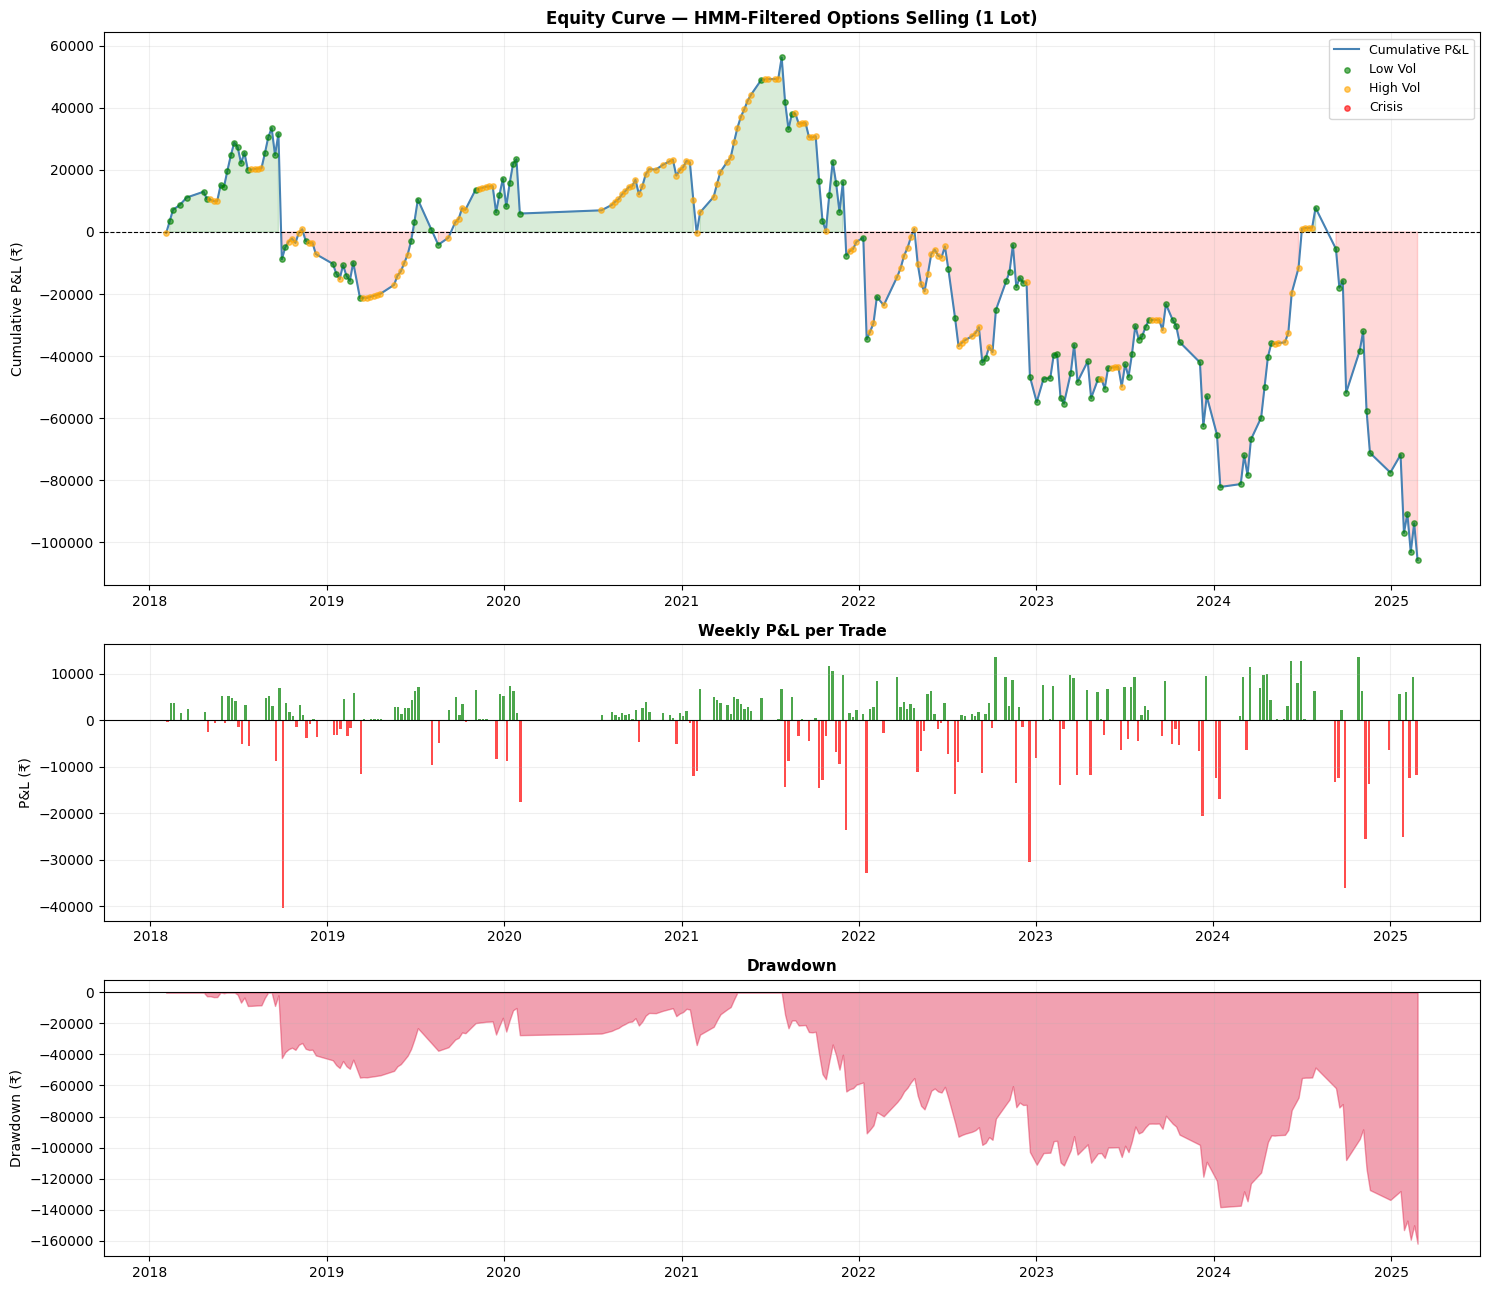

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(15, 13),
                          gridspec_kw={"height_ratios": [3, 1.5, 1.5]})

# ── Panel 1: Equity Curve ──────────────────────────────────────────
ax = axes[0]
ax.plot(bt["entry_date"], bt["cum_pnl"],
        color="steelblue", linewidth=1.5, label="Cumulative P&L")
ax.fill_between(bt["entry_date"], bt["cum_pnl"], 0,
                where=bt["cum_pnl"] >= 0, alpha=0.15, color="green")
ax.fill_between(bt["entry_date"], bt["cum_pnl"], 0,
                where=bt["cum_pnl"] < 0,  alpha=0.15, color="red")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Colour dots by regime
for regime, color in [("Low Vol","green"),("High Vol","orange"),("Crisis","red")]:
    mask = bt["regime"] == regime
    ax.scatter(bt.loc[mask, "entry_date"], bt.loc[mask, "cum_pnl"],
               s=15, color=color, alpha=0.6, zorder=4, label=regime)

ax.set_title("Equity Curve — HMM-Filtered Options Selling (1 Lot)",
             fontweight="bold", fontsize=12)
ax.set_ylabel("Cumulative P&L (₹)")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

# ── Panel 2: Weekly P&L Bar Chart ─────────────────────────────────
ax2 = axes[1]
colors_bar = ["green" if x > 0 else "red" for x in bt["pnl_per_lot"]]
ax2.bar(bt["entry_date"], bt["pnl_per_lot"],
        color=colors_bar, alpha=0.7, width=5)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_title("Weekly P&L per Trade", fontweight="bold", fontsize=11)
ax2.set_ylabel("P&L (₹)")
ax2.grid(alpha=0.2)

# ── Panel 3: Drawdown ──────────────────────────────────────────────
ax3 = axes[2]
ax3.fill_between(bt["entry_date"], bt["drawdown"], 0,
                 color="crimson", alpha=0.4)
ax3.axhline(0, color="black", linewidth=0.8)
ax3.set_title("Drawdown", fontweight="bold", fontsize=11)
ax3.set_ylabel("Drawdown (₹)")
ax3.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [33]:
# Know your worst weeks — critical for risk management
print("\n── Top 10 Worst Trades ────────────────────────────────────")
worst = bt.nsmallest(10, "pnl_per_lot")[
    ["entry_date","strategy","regime","spot_move_pct",
     "premium_collected","cost_to_close","pnl_per_lot","vix"]
]
print(worst.to_string())

print("\n── Top 10 Best Trades ─────────────────────────────────────")
best = bt.nlargest(10, "pnl_per_lot")[
    ["entry_date","strategy","regime","spot_move_pct",
     "premium_collected","cost_to_close","pnl_per_lot","vix"]
]
print(best.to_string())


── Top 10 Worst Trades ────────────────────────────────────
    entry_date        strategy   regime  spot_move_pct  premium_collected  cost_to_close  pnl_per_lot    vix
28  2018-10-01  short_straddle  Low Vol          -6.28             142.82         682.13    -40448.25  16.84
251 2024-09-30  short_straddle  Low Vol          -3.08             301.87         782.07    -36015.49  12.79
147 2022-01-17  short_straddle  Low Vol          -3.77             243.50         680.49    -32774.50  16.77
187 2022-12-19  short_straddle  Low Vol          -3.33             185.05         590.83    -30433.05  13.55
254 2024-11-11  short_straddle  Low Vol          -2.52             274.30         614.19    -25491.31  14.27
258 2025-01-27  short_straddle  Low Vol           2.98             326.03         661.35    -25149.05  18.13
142 2021-12-06  short_straddle  Low Vol           3.54             297.38         613.48    -23707.22  20.08
225 2023-12-11  short_straddle  Low Vol           2.19             

In [35]:
# ── Improved parameters ────────────────────────────────────────────
STOP_LOSS_MULT  = 2.0    # Exit if loss > 2x premium collected
USE_VIX_SIGMA   = True   # Use VIX-implied vol instead of realised vol
MAX_SPOT_MOVE   = 0.015  # Skip entry if Monday gap > 1.5% from Friday

results_v2 = []

price_series = prices["^NSEI"]
vol_series   = features["vol_long"]
vix_series   = features["vix_level"]

for entry_date, row in signals_df[signals_df["enter"]].iterrows():

    # ── Find exit date ─────────────────────────────────────────────
    week_prices = price_series.loc[
        entry_date : entry_date + pd.Timedelta(days=6)
    ]
    if len(week_prices) < 2:
        continue

    S_entry = week_prices.iloc[0]

    # ── Gap filter: skip if Monday opened too far from last Friday ──
    prev_close_idx = price_series.index[price_series.index < entry_date]
    if len(prev_close_idx) == 0:
        continue
    S_prev = price_series.loc[prev_close_idx[-1]]
    gap    = abs(S_entry / S_prev - 1)
    if gap > MAX_SPOT_MOVE:
        continue

    # ── Sigma: use VIX/sqrt(252) as forward-looking vol ───────────
    if USE_VIX_SIGMA:
        sigma = (vix_series.loc[entry_date] / 100)
    else:
        sigma = vol_series.loc[entry_date]

    T_entry = 4 / 252

    # ── Strike selection ───────────────────────────────────────────
    if row["strategy"] == "short_straddle":
        K_call = round(S_entry / 50) * 50
        K_put  = K_call
    else:
        K_call = round(S_entry * 1.02 / 50) * 50
        K_put  = round(S_entry * 0.98 / 50) * 50

    size = row["size_mult"]

    call_entry = bs_price(S_entry, K_call, T_entry, RISK_FREE, sigma, "call")
    put_entry  = bs_price(S_entry, K_put,  T_entry, RISK_FREE, sigma, "put")
    premium_collected = (call_entry + put_entry) * size
    stop_level = premium_collected * STOP_LOSS_MULT

    # ── Intraweek stop loss simulation ────────────────────────────
    stopped_out = False
    exit_date   = week_prices.index[min(4, len(week_prices)-1)]
    S_exit      = week_prices.iloc[min(4, len(week_prices)-1)]

    for day_price in week_prices.iloc[1:]:
        T_remaining = max((4 - list(week_prices).index(day_price)) / 252,
                           0.5/252)
        call_now = bs_price(day_price, K_call, T_remaining, RISK_FREE, sigma, "call")
        put_now  = bs_price(day_price, K_put,  T_remaining, RISK_FREE, sigma, "put")
        current_loss = ((call_now + put_now) * size) - premium_collected

        if current_loss >= stop_level:
            stopped_out = True
            S_exit      = day_price
            cost_to_close = (call_now + put_now) * size
            break

    if not stopped_out:
        T_exit = 0.5 / 252
        call_exit = bs_price(S_exit, K_call, T_exit, RISK_FREE, sigma, "call")
        put_exit  = bs_price(S_exit, K_put,  T_exit, RISK_FREE, sigma, "put")
        cost_to_close = (call_exit + put_exit) * size

    pnl_per_lot = (premium_collected - cost_to_close) * NIFTY_LOT_SIZE

    results_v2.append({
        "entry_date"       : entry_date,
        "exit_date"        : exit_date,
        "strategy"         : row["strategy"],
        "regime"           : row["regime"],
        "S_entry"          : round(S_entry, 0),
        "S_exit"           : round(S_exit, 0),
        "spot_move_pct"    : round((S_exit / S_entry - 1) * 100, 2),
        "premium_collected": round(premium_collected, 2),
        "cost_to_close"    : round(cost_to_close, 2),
        "pnl_per_lot"      : round(pnl_per_lot, 2),
        "stopped_out"      : stopped_out,
        "gap_pct"          : round(gap * 100, 2),
        "vix"              : row["vix"],
        "iv_premium"       : row["iv_premium"],
        "sigma_used"       : round(sigma, 4)
    })

bt2 = pd.DataFrame(results_v2).sort_values("entry_date").reset_index(drop=True)
print(f"Trades after gap filter: {len(bt2)}")
print(f"Stopped out: {bt2['stopped_out'].sum()} ({bt2['stopped_out'].mean()*100:.1f}%) multipliers)")

Trades after gap filter: 231
Stopped out: 4 (1.7%) multipliers)


In [36]:
bt2["cum_pnl"]     = bt2["pnl_per_lot"].cumsum()
bt2["running_max"] = bt2["cum_pnl"].cummax()
bt2["drawdown"]    = bt2["cum_pnl"] - bt2["running_max"]

total_trades  = len(bt2)
winners       = (bt2["pnl_per_lot"] > 0).sum()
win_rate      = winners / total_trades * 100
avg_win       = bt2.loc[bt2["pnl_per_lot"] > 0, "pnl_per_lot"].mean()
avg_loss      = bt2.loc[bt2["pnl_per_lot"] < 0, "pnl_per_lot"].mean()
profit_factor = abs(bt2.loc[bt2["pnl_per_lot"] > 0, "pnl_per_lot"].sum() /
                    bt2.loc[bt2["pnl_per_lot"] < 0, "pnl_per_lot"].sum())
total_pnl     = bt2["pnl_per_lot"].sum()
max_dd        = bt2["drawdown"].min()
weekly_ret    = bt2["pnl_per_lot"] / CAPITAL
sharpe        = (weekly_ret.mean() / weekly_ret.std()) * np.sqrt(52)

print("═" * 50)
print("  BACKTEST V2 — WITH STOP LOSS + VIX SIGMA")
print("═" * 50)
print(f"  Period            : {bt2['entry_date'].min().date()} → {bt2['entry_date'].max().date()}")
print(f"  Total trades      : {total_trades}")
print(f"  Win rate          : {win_rate:.1f}%")
print(f"  Avg win / loss    : ₹{avg_win:,.0f} / ₹{avg_loss:,.0f}")
print(f"  Profit factor     : {profit_factor:.2f}")
print(f"  Total P&L (1 lot) : ₹{total_pnl:,.0f}")
print(f"  Max drawdown      : ₹{max_dd:,.0f}")
print(f"  Sharpe ratio      : {sharpe:.2f}")
print("═" * 50)

print("\nP&L by regime:")
print(bt2.groupby("regime")["pnl_per_lot"].agg(
    trades="count",
    total_pnl="sum",
    avg_pnl="mean",
    win_rate=lambda x: (x>0).mean()*100
).round(2).to_string())

print("\nP&L by strategy:")
print(bt2.groupby("strategy")["pnl_per_lot"].agg(
    trades="count",
    total_pnl="sum",
    avg_pnl="mean",
    win_rate=lambda x: (x>0).mean()*100
).round(2).to_string())

══════════════════════════════════════════════════
  BACKTEST V2 — WITH STOP LOSS + VIX SIGMA
══════════════════════════════════════════════════
  Period            : 2018-02-05 → 2025-02-24
  Total trades      : 231
  Win rate          : 76.2%
  Avg win / loss    : ₹4,925 / ₹-7,846
  Profit factor     : 2.01
  Total P&L (1 lot) : ₹435,273
  Max drawdown      : ₹-47,572
  Sharpe ratio      : 1.79
══════════════════════════════════════════════════

P&L by regime:
          trades  total_pnl  avg_pnl  win_rate
regime                                        
High Vol     111  171429.00  1544.41     87.39
Low Vol      120  263844.05  2198.70     65.83

P&L by strategy:
                trades  total_pnl  avg_pnl  win_rate
strategy                                            
short_straddle     120  263844.05  2198.70     65.83
short_strangle     111  171429.00  1544.41     87.39


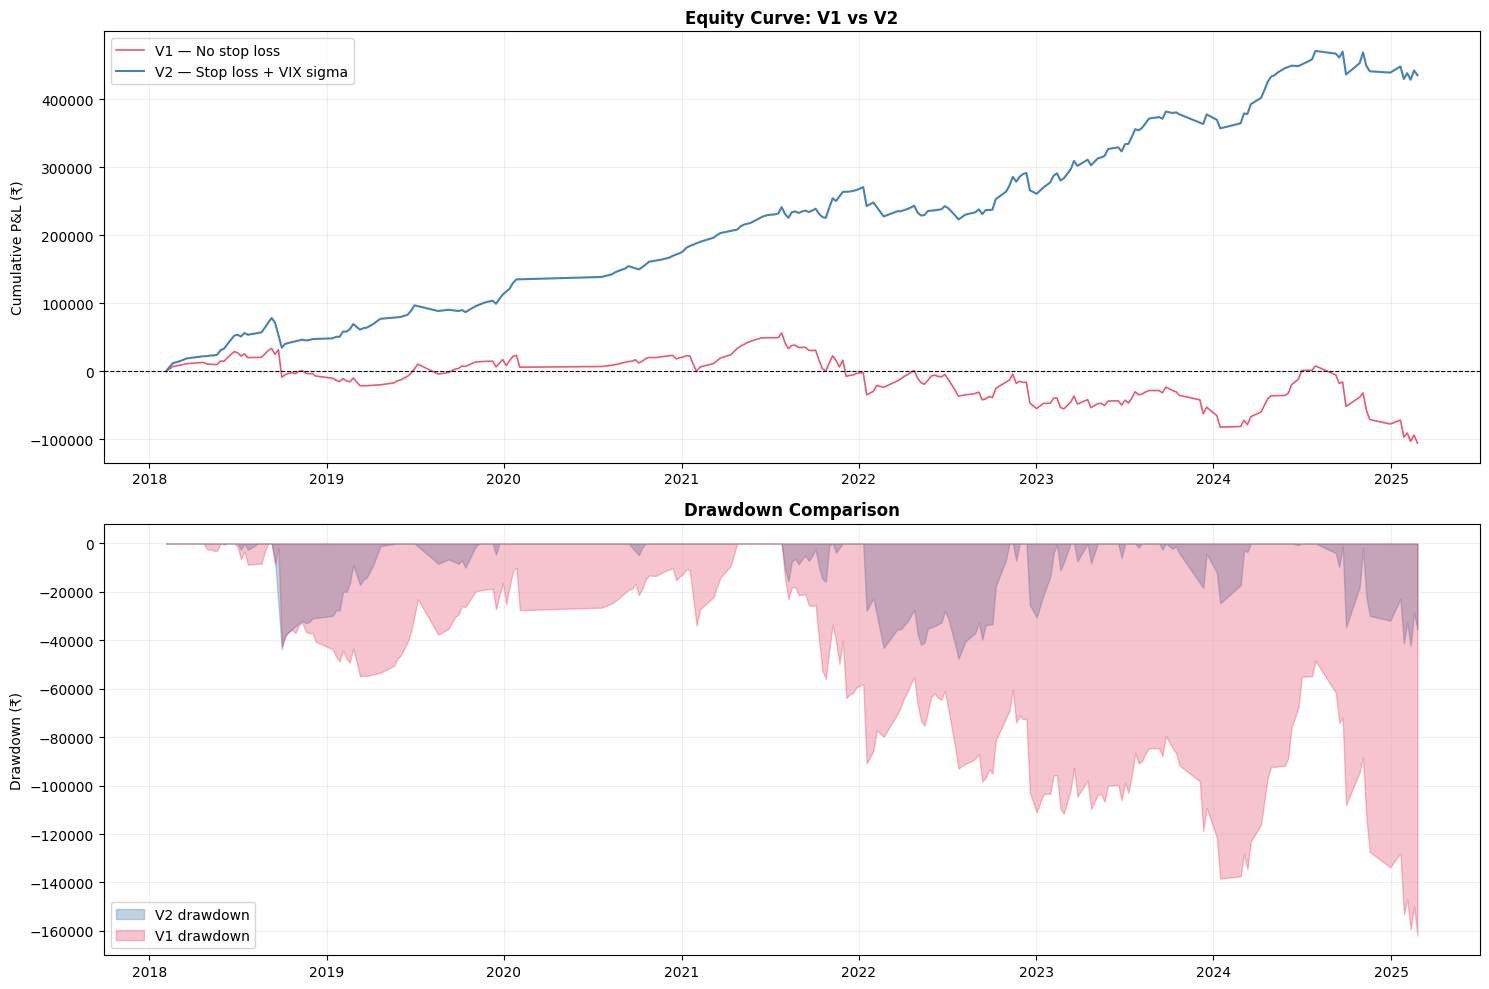

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Align on common dates
common = bt2["entry_date"]
v1_curve = bt[bt["entry_date"].isin(common)].set_index("entry_date")["cum_pnl"]

ax1 = axes[0]
ax1.plot(bt["entry_date"], bt["cum_pnl"],
         color="crimson", linewidth=1.2, alpha=0.7, label="V1 — No stop loss")
ax1.plot(bt2["entry_date"], bt2["cum_pnl"],
         color="steelblue", linewidth=1.5, label="V2 — Stop loss + VIX sigma")
ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax1.set_title("Equity Curve: V1 vs V2", fontweight="bold", fontsize=12)
ax1.set_ylabel("Cumulative P&L (₹)")
ax1.legend()
ax1.grid(alpha=0.2)

ax2 = axes[1]
ax2.fill_between(bt2["entry_date"], bt2["drawdown"], 0,
                 color="steelblue", alpha=0.35, label="V2 drawdown")
ax2.fill_between(bt["entry_date"], bt["drawdown"], 0,
                 color="crimson", alpha=0.25, label="V1 drawdown")
ax2.set_title("Drawdown Comparison", fontweight="bold", fontsize=12)
ax2.set_ylabel("Drawdown (₹)")
ax2.legend()
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [38]:
pip install pydmd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.7/152.7 kB 3.1 MB/s eta 0:00:00


In [42]:
from pydmd import DMD, BOPDMD
import warnings
warnings.filterwarnings("ignore")

# ── Prepare data for DMD ───────────────────────────────────────────
# DMD expects matrix of shape (n_features, n_timesteps)
# We'll use a delay-embedding: stack lagged returns as features
# This is the Hankel-DMD approach — captures temporal dynamics

DELAY     = 10   # number of lags (embedding dimension)
nifty_ret = returns["^NSEI_ret"].values

def hankel_matrix(x, delays):
    """Build delay-embedded (Hankel) matrix from 1D time series."""
    n = len(x) - delays + 1
    return np.array([x[i:i+n] for i in range(delays)])

X_hankel = hankel_matrix(nifty_ret, DELAY)
print(f"Hankel matrix shape: {X_hankel.shape}")
# Shape: (10 lags, n_timesteps)

# ── Fit DMD ────────────────────────────────────────────────────────
dmd = DMD(svd_rank=6)   # keep top 6 modes
dmd.fit(X_hankel)

print(f"\nDMD eigenvalues (top 6 modes):")
for i, eig in enumerate(dmd.eigs):
    freq     = np.angle(eig) / (2 * np.pi)   # cycles per timestep
    growth   = np.abs(eig)                    # >1 growing, <1 decaying
    period   = abs(1/freq) if freq != 0 else np.inf
    print(f"  Mode {i+1}: |λ|={growth:.4f}  freq={freq:.4f}  "
          f"period≈{period:.1f} days  "
          f"{'📈 Growing' if growth>1.01 else '📉 Decaying' if growth<0.99 else '🔄 Neutral'}")

Hankel matrix shape: (10, 1740)

DMD eigenvalues (top 6 modes):
  Mode 1: |λ|=0.9274  freq=0.4222  period≈2.4 days  📉 Decaying
  Mode 2: |λ|=0.9274  freq=-0.4222  period≈2.4 days  📉 Decaying
  Mode 3: |λ|=0.8627  freq=0.2358  period≈4.2 days  📉 Decaying
  Mode 4: |λ|=0.8627  freq=-0.2358  period≈4.2 days  📉 Decaying
  Mode 5: |λ|=0.8736  freq=0.0000  period≈inf days  📉 Decaying
  Mode 6: |λ|=0.2183  freq=0.0000  period≈inf days  📉 Decaying


In [43]:
# ── Reconstruct DMD signal and compute mode contributions ─────────
# The key insight: if dominant modes are NEUTRAL (|λ|≈1) → market
# is in a stable oscillatory regime → safe to sell options
# If dominant modes are GROWING (|λ|>1) → trending/explosive → risky

dmd_dynamics  = dmd.dynamics          # shape: (n_modes, n_timesteps)
dmd_amplitudes = np.abs(dmd.amplitudes)

# Weighted mode stability score per timestep
# Score close to 1.0 = dominant modes near unit circle = calm market
eig_mags = np.abs(dmd.eigs)           # |λ| for each mode
weights  = dmd_amplitudes / dmd_amplitudes.sum()   # amplitude weights

stability_score = np.sum(weights * eig_mags)
print(f"\nGlobal DMD stability score: {stability_score:.4f}")
print("(1.0 = perfectly neutral, >1 = explosive modes dominant)")

# ── Rolling DMD stability (walk-forward) ──────────────────────────
# Refit DMD on rolling 126-day (6-month) windows
# This gives us a time-varying stability score

WINDOW = 126
stability_ts = []
dates_ts     = []

for i in range(WINDOW, len(nifty_ret)):
    window_data = nifty_ret[i-WINDOW:i]
    X_w = hankel_matrix(window_data, DELAY)
    try:
        dmd_w = DMD(svd_rank=4)
        dmd_w.fit(X_w)
        eigs_w = np.abs(dmd_w.eigs)
        amps_w = np.abs(dmd_w.amplitudes)
        w      = amps_w / (amps_w.sum() + 1e-10)
        score  = float(np.sum(w * eigs_w))
    except:
        score  = 1.0   # fallback if DMD fails
    stability_ts.append(score)
    dates_ts.append(returns.index[i])

dmd_stability = pd.Series(stability_ts, index=dates_ts, name="dmd_stability")
print(f"\nRolling DMD stability computed: {len(dmd_stability)} points")
print(f"Mean: {dmd_stability.mean():.4f}  Std: {dmd_stability.std():.4f}")
print(f"Range: [{dmd_stability.min():.4f}, {dmd_stability.max():.4f}]")


Global DMD stability score: 0.8006
(1.0 = perfectly neutral, >1 = explosive modes dominant)

Rolling DMD stability computed: 1623 points
Mean: 0.7900  Std: 0.1328
Range: [0.1760, 0.9572]


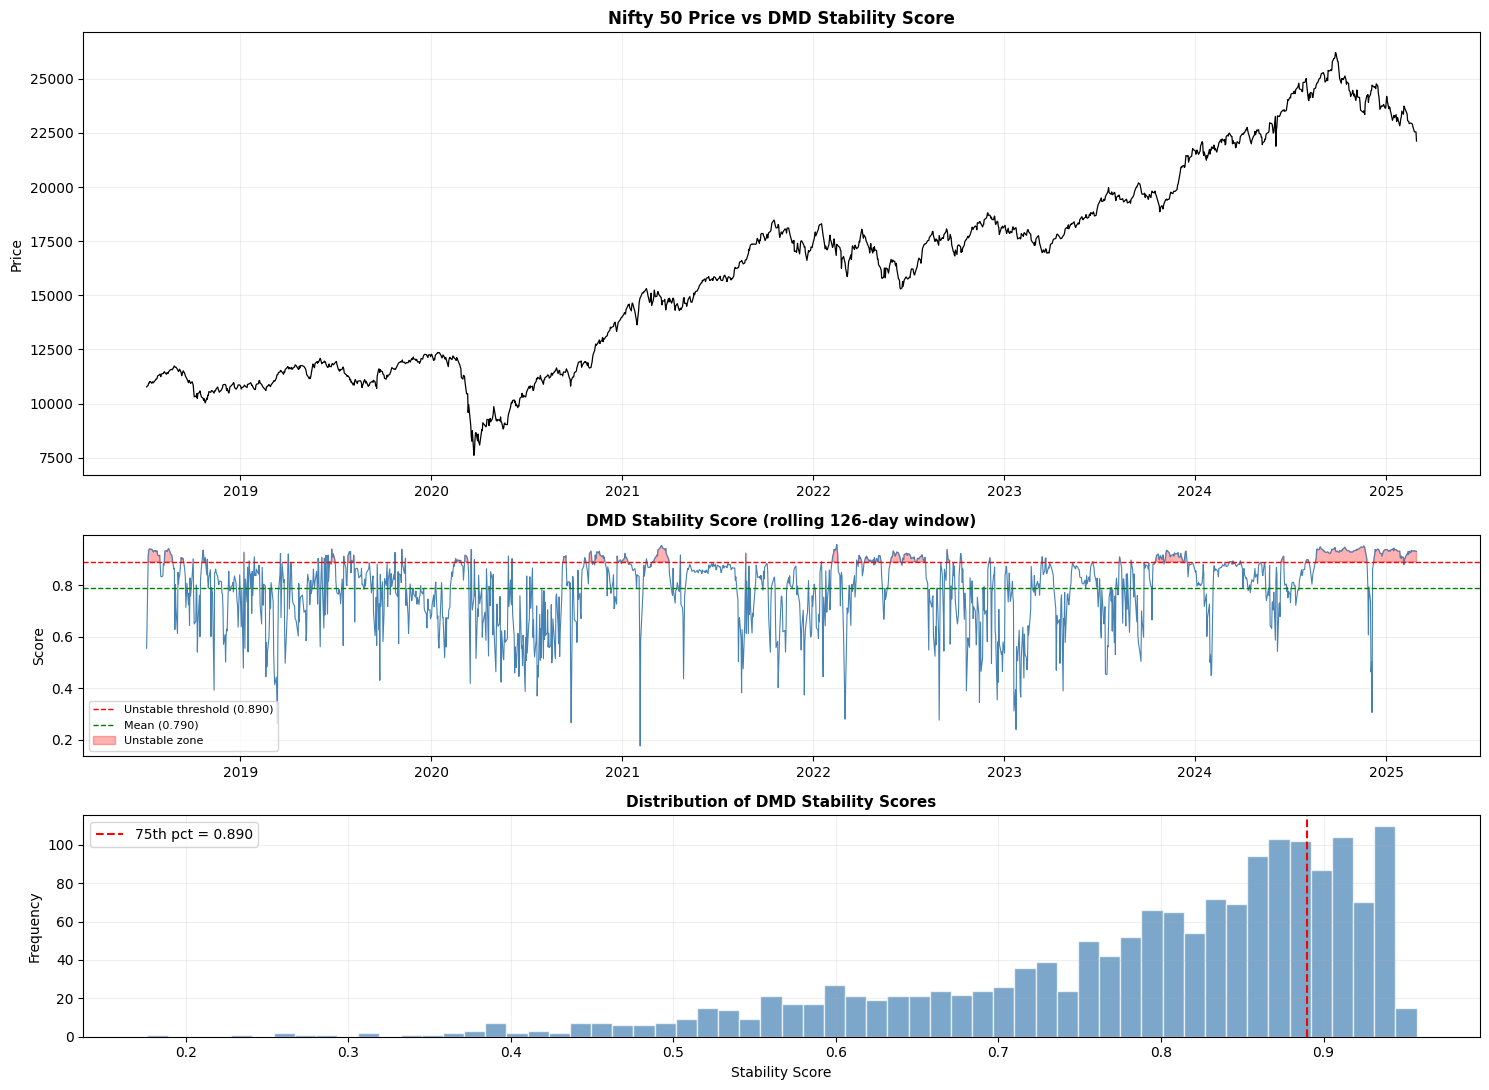

In [45]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 11),
                                      gridspec_kw={"height_ratios":[2,1,1]})

# ── Nifty price ────────────────────────────────────────────────────
nifty_aligned = prices["^NSEI"].loc[dmd_stability.index]
ax1.plot(nifty_aligned.index, nifty_aligned.values,
         color="black", linewidth=0.9)
ax1.set_title("Nifty 50 Price vs DMD Stability Score",
              fontweight="bold", fontsize=12)
ax1.set_ylabel("Price")
ax1.grid(alpha=0.2)

# ── DMD stability score ────────────────────────────────────────────
threshold = dmd_stability.quantile(0.75)   # top 25% = unstable
ax2.plot(dmd_stability.index, dmd_stability.values,
         color="steelblue", linewidth=0.8)
ax2.axhline(threshold, color="red", linestyle="--",
            linewidth=1, label=f"Unstable threshold ({threshold:.3f})")
ax2.axhline(dmd_stability.mean(), color="green", linestyle="--",
            linewidth=1, label=f"Mean ({dmd_stability.mean():.3f})")
ax2.fill_between(dmd_stability.index, dmd_stability.values, threshold,
                 where=dmd_stability.values > threshold,
                 alpha=0.3, color="red", label="Unstable zone")
ax2.set_title("DMD Stability Score (rolling 126-day window)",
              fontweight="bold", fontsize=11)
ax2.set_ylabel("Score")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)

# ── Distribution of scores ─────────────────────────────────────────
ax3.hist(dmd_stability.values, bins=60, color="steelblue",
         alpha=0.7, edgecolor="white")
ax3.axvline(threshold, color="red", linestyle="--", linewidth=1.5,
            label=f"75th pct = {threshold:.3f}")
ax3.set_title("Distribution of DMD Stability Scores",
              fontweight="bold", fontsize=11)
ax3.set_xlabel("Stability Score")
ax3.set_ylabel("Frequency")
ax3.legend()
ax3.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [46]:
# Add DMD stability filter to signal_df
# Only enter trade if DMD score < 75th percentile (stable market)

STABILITY_THRESHOLD = dmd_stability.quantile(0.75)

results_v3 = []

for _, row in bt2.iterrows():
    entry_date = row["entry_date"]

    # Get DMD score for this week
    if entry_date not in dmd_stability.index:
        # Find nearest available date
        available = dmd_stability.index[dmd_stability.index <= entry_date]
        if len(available) == 0:
            continue
        dmd_score = dmd_stability.loc[available[-1]]
    else:
        dmd_score = dmd_stability.loc[entry_date]

    # DMD filter: skip if market is in unstable mode
    if dmd_score > STABILITY_THRESHOLD:
        continue

    row_dict = row.to_dict()
    row_dict["dmd_score"] = round(dmd_score, 4)
    results_v3.append(row_dict)

bt3 = pd.DataFrame(results_v3).sort_values("entry_date").reset_index(drop=True)
bt3["cum_pnl"]     = bt3["pnl_per_lot"].cumsum()
bt3["running_max"] = bt3["cum_pnl"].cummax()
bt3["drawdown"]    = bt3["cum_pnl"] - bt3["running_max"]

# ── Performance V3 ─────────────────────────────────────────────────
total_trades  = len(bt3)
winners       = (bt3["pnl_per_lot"] > 0).sum()
win_rate      = winners / total_trades * 100
avg_win       = bt3.loc[bt3["pnl_per_lot"] > 0, "pnl_per_lot"].mean()
avg_loss      = bt3.loc[bt3["pnl_per_lot"] < 0, "pnl_per_lot"].mean()
profit_factor = abs(bt3.loc[bt3["pnl_per_lot"] > 0, "pnl_per_lot"].sum() /
                    bt3.loc[bt3["pnl_per_lot"] < 0, "pnl_per_lot"].sum())
total_pnl     = bt3["pnl_per_lot"].sum()
max_dd        = bt3["drawdown"].min()
weekly_ret    = bt3["pnl_per_lot"] / CAPITAL
sharpe        = (weekly_ret.mean() / weekly_ret.std()) * np.sqrt(52)

print("═" * 55)
print("  BACKTEST V3 — DMD STABILITY FILTER ADDED")
print("═" * 55)
print(f"  Trades (V2 → V3)  : {len(bt2)} → {total_trades} "
      f"(filtered {len(bt2)-total_trades} unstable weeks)")
print(f"  Win rate          : {win_rate:.1f}%")
print(f"  Avg win / loss    : ₹{avg_win:,.0f} / ₹{avg_loss:,.0f}")
print(f"  Profit factor     : {profit_factor:.2f}")
print(f"  Total P&L (1 lot) : ₹{total_pnl:,.0f}")
print(f"  Max drawdown      : ₹{max_dd:,.0f}")
print(f"  Sharpe ratio      : {sharpe:.2f}")
print("═" * 55)

# V2 vs V3 comparison
print(f"\n{'Metric':<22} {'V2':>12} {'V3':>12} {'Delta':>12}")
print("-" * 58)
metrics = [
    ("Total P&L (₹)",    bt2["pnl_per_lot"].sum(),     total_pnl),
    ("Win rate (%)",     (bt2["pnl_per_lot"]>0).mean()*100, win_rate),
    ("Profit factor",    2.01,                          profit_factor),
    ("Max DD (₹)",       bt2["drawdown"].min(),         max_dd),
    ("Sharpe",           1.79,                          sharpe),
]
for name, v2_val, v3_val in metrics:
    delta = v3_val - v2_val
    print(f"  {name:<20} {v2_val:>12,.2f} {v3_val:>12,.2f} "
          f"{'▲' if delta>0 else '▼'}{abs(delta):,.2f}")

═══════════════════════════════════════════════════════
  BACKTEST V3 — DMD STABILITY FILTER ADDED
═══════════════════════════════════════════════════════
  Trades (V2 → V3)  : 231 → 167 (filtered 64 unstable weeks)
  Win rate          : 78.4%
  Avg win / loss    : ₹4,920 / ₹-7,309
  Profit factor     : 2.45
  Total P&L (1 lot) : ₹381,466
  Max drawdown      : ₹-43,739
  Sharpe ratio      : 2.35
═══════════════════════════════════════════════════════

Metric                           V2           V3        Delta
----------------------------------------------------------
  Total P&L (₹)          435,273.05   381,465.78 ▼53,807.27
  Win rate (%)                76.19        78.44 ▲2.25
  Profit factor                2.01         2.45 ▲0.44
  Max DD (₹)             -47,571.61   -43,738.76 ▲3,832.85
  Sharpe                       1.79         2.35 ▲0.56


In [48]:
wf_results = []

print("═" * 65)
print("  WALK-FORWARD VALIDATION (FIXED)")
print("═" * 65)

for test_start_year in range(start_year + TRAIN_YEARS, end_year):

    train_end  = pd.Timestamp(f"{test_start_year}-01-01")
    test_end   = pd.Timestamp(f"{test_start_year + TEST_YEARS}-01-01")

    train_mask = features.index < train_end
    test_mask  = (features.index >= train_end) & (features.index < test_end)

    if train_mask.sum() < 100 or test_mask.sum() < 20:
        continue

    X_train = features.loc[train_mask, HMM_FEATURES]
    X_test  = features.loc[test_mask,  HMM_FEATURES]

    sc      = StandardScaler()
    Xtr_s   = sc.fit_transform(X_train)
    Xte_s   = sc.transform(X_test)

    hmm_wf  = GaussianHMM(n_components=3, covariance_type="full",
                           n_iter=2000, random_state=42)
    hmm_wf.fit(Xtr_s)

    # Decode test regimes
    test_regimes_raw = hmm_wf.predict(Xte_s)
    vix_by_s = {
        s: features.loc[test_mask, "vix_level"][test_regimes_raw == s].median()
        for s in range(3)
    }
    sorted_s = sorted(vix_by_s, key=vix_by_s.get)
    smap     = {sorted_s[0]: 0, sorted_s[1]: 1, sorted_s[2]: 2}

    test_regime_series = pd.Series(
        [smap[r] for r in test_regimes_raw],
        index=features.index[test_mask]
    )

    # ── KEY FIX: resample to WEEKLY (Monday) entries only ─────────
    test_price_weekly = (
        price_series
        .loc[test_regime_series.index]
        .resample("W-MON").first()
        .dropna()
    )

    period_pnl = []

    for entry_date in test_price_weekly.index:

        # Match entry_date to nearest available regime date
        available = test_regime_series.index[
            test_regime_series.index <= entry_date
        ]
        if len(available) == 0:
            continue
        regime_date = available[-1]

        # Only use if within 3 days (avoid stale regime)
        if (entry_date - regime_date).days > 3:
            continue

        regime = test_regime_series.loc[regime_date]
        ivp    = features.loc[regime_date, "iv_premium"]
        vix    = features.loc[regime_date, "vix_level"]
        sig    = get_signal(regime, ivp, vix)

        if not sig["enter"]:
            continue

        # ── Gap filter ─────────────────────────────────────────────
        week_prices = price_series.loc[
            entry_date : entry_date + pd.Timedelta(days=6)
        ]
        if len(week_prices) < 2:
            continue

        S_entry   = week_prices.iloc[0]
        prev_idx  = price_series.index[price_series.index < entry_date]
        if len(prev_idx) == 0:
            continue

        gap = abs(S_entry / price_series.loc[prev_idx[-1]] - 1)
        if gap > MAX_SPOT_MOVE:
            continue

        # ── Sigma, strikes ─────────────────────────────────────────
        sigma  = features.loc[regime_date, "vix_level"] / 100
        size   = sig["size_mult"]

        if sig["strategy"] == "short_straddle":
            K_call = K_put = round(S_entry / 50) * 50
        else:
            K_call = round(S_entry * 1.02 / 50) * 50
            K_put  = round(S_entry * 0.98 / 50) * 50

        T_entry = 4 / 252
        call_e  = bs_price(S_entry, K_call, T_entry, RISK_FREE, sigma, "call")
        put_e   = bs_price(S_entry, K_put,  T_entry, RISK_FREE, sigma, "put")
        premium = (call_e + put_e) * size
        stop    = premium * STOP_LOSS_MULT

        # ── Intraweek stop check ───────────────────────────────────
        stopped = False
        S_exit  = week_prices.iloc[min(4, len(week_prices)-1)]
        cost    = (
            bs_price(S_exit, K_call, 0.5/252, RISK_FREE, sigma, "call") +
            bs_price(S_exit, K_put,  0.5/252, RISK_FREE, sigma, "put")
        ) * size

        for j, dp in enumerate(week_prices.iloc[1:], start=1):
            T_rem = max(0.5/252, (4-j)/252)
            c_now = bs_price(dp, K_call, T_rem, RISK_FREE, sigma, "call")
            p_now = bs_price(dp, K_put,  T_rem, RISK_FREE, sigma, "put")
            if ((c_now + p_now) * size - premium) >= stop:
                cost    = (c_now + p_now) * size
                stopped = True
                break

        pnl = (premium - cost) * NIFTY_LOT_SIZE
        period_pnl.append(pnl)

    if not period_pnl:
        continue

    period_pnl = np.array(period_pnl)
    wr   = (period_pnl > 0).mean() * 100
    tot  = period_pnl.sum()
    pos  = period_pnl[period_pnl > 0].sum()
    neg  = abs(period_pnl[period_pnl < 0].sum())
    pf   = pos / neg if neg > 0 else np.inf
    sr   = (period_pnl.mean() / (period_pnl.std() + 1e-10)) * np.sqrt(52)

    wf_results.append({
        "test_year": test_start_year,
        "trades"   : len(period_pnl),
        "win_rate" : round(wr, 1),
        "total_pnl": round(tot, 0),
        "avg_pnl"  : round(period_pnl.mean(), 0),
        "pf"       : round(pf, 2),
        "sharpe"   : round(sr, 2)
    })

    print(f"  {test_start_year}  "
          f"trades={len(period_pnl):>3}  "
          f"WR={wr:.1f}%  "
          f"PF={pf:.2f}  "
          f"P&L=₹{tot:>8,.0f}  "
          f"Sharpe={sr:.2f}")

wf_df = pd.DataFrame(wf_results)

print("\n── Aggregate Walk-Forward Stats ────────────────────────")
print(f"  Years tested      : {len(wf_df)}")
print(f"  Years profitable  : {(wf_df['total_pnl'] > 0).sum()} / {len(wf_df)}")
print(f"  Avg annual P&L    : ₹{wf_df['total_pnl'].mean():,.0f}")
print(f"  Avg win rate      : {wf_df['win_rate'].mean():.1f}%")
print(f"  Avg Sharpe        : {wf_df['sharpe'].mean():.2f}")
print(f"  Worst year P&L    : ₹{wf_df['total_pnl'].min():,.0f}")
print(f"  Best year P&L     : ₹{wf_df['total_pnl'].max():,.0f}")

═════════════════════════════════════════════════════════════════
  WALK-FORWARD VALIDATION (FIXED)
═════════════════════════════════════════════════════════════════
  2022  trades= 36  WR=75.0%  PF=1.42  P&L=₹  34,172  Sharpe=0.95
  2023  trades= 36  WR=69.4%  PF=1.98  P&L=₹  88,632  Sharpe=2.05
  2024  trades=  4  WR=100.0%  PF=inf  P&L=₹  33,407  Sharpe=12.14

── Aggregate Walk-Forward Stats ────────────────────────
  Years tested      : 3
  Years profitable  : 3 / 3
  Avg annual P&L    : ₹52,070
  Avg win rate      : 81.5%
  Avg Sharpe        : 5.05
  Worst year P&L    : ₹33,407
  Best year P&L     : ₹88,632


═════════════════════════════════════════════════════════════════
  WALK-FORWARD VALIDATION (FINAL)
═════════════════════════════════════════════════════════════════
  2021  NO TRADES GENERATED
  2022  trades= 35  WR=71.4%  PF=1.20  P&L=₹   16,891  Sharpe=0.49
  2023  trades= 35  WR=68.6%  PF=1.39  P&L=₹   47,513  Sharpe=0.89
  2024  trades=  5  WR=100.0%  PF=99.00  P&L=₹   50,294  Sharpe=20.15

── Aggregate Walk-Forward Stats ────────────────────────
  Years tested      : 3
  Years profitable  : 3 / 3
  Avg annual P&L    : ₹38,233
  Avg win rate      : 80.0%
  Avg Sharpe        : 7.18
  Avg profit factor : 1.29  (excl. inf years)
  Worst year P&L    : ₹16,891
  Best year P&L     : ₹50,294


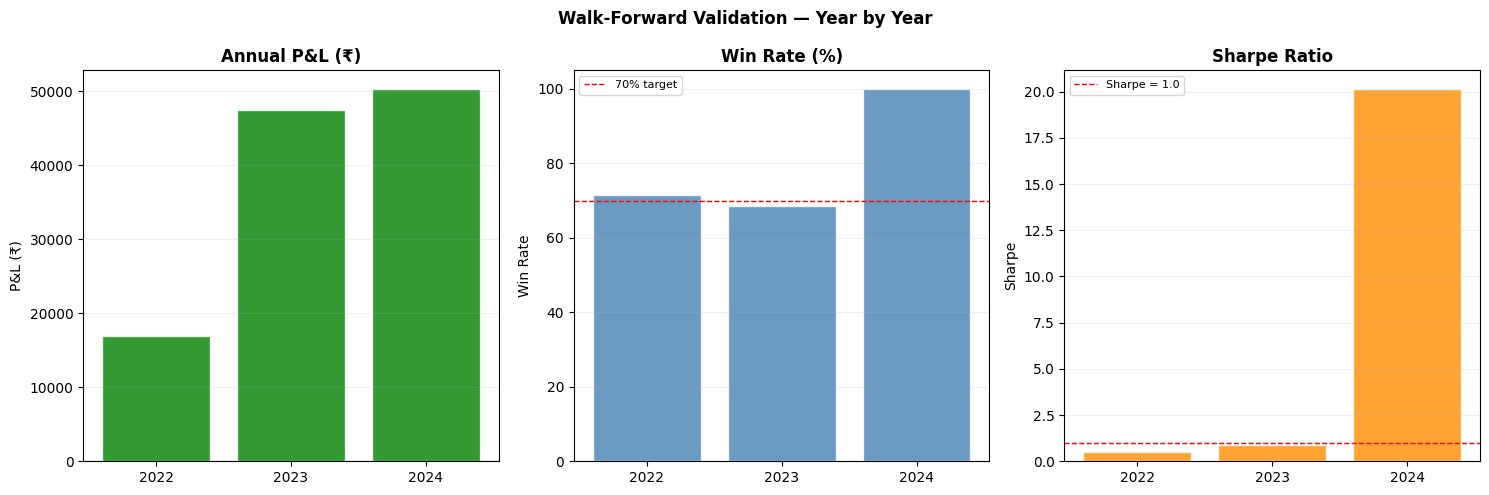

In [49]:
wf_results = []

# ── Fix 1: extend range to include all years ──────────────────────
TEST_YEARS_RANGE = range(2021, 2025)

print("═" * 65)
print("  WALK-FORWARD VALIDATION (FINAL)")
print("═" * 65)

for test_start_year in TEST_YEARS_RANGE:

    train_end = pd.Timestamp(f"{test_start_year}-01-01")
    test_end  = pd.Timestamp(f"{test_start_year + 1}-01-01")

    train_mask = features.index < train_end
    test_mask  = (features.index >= train_end) & (features.index < test_end)

    if train_mask.sum() < 50 or test_mask.sum() < 10:
        print(f"  {test_start_year}  SKIPPED — insufficient data "
              f"(train={train_mask.sum()}, test={test_mask.sum()})")
        continue

    # ── Fit HMM on train ───────────────────────────────────────────
    X_train = features.loc[train_mask, HMM_FEATURES]
    X_test  = features.loc[test_mask,  HMM_FEATURES]

    sc      = StandardScaler()
    Xtr_s   = sc.fit_transform(X_train)
    Xte_s   = sc.transform(X_test)

    hmm_wf  = GaussianHMM(n_components=3, covariance_type="full",
                           n_iter=2000, random_state=42)
    hmm_wf.fit(Xtr_s)

    test_regimes_raw = hmm_wf.predict(Xte_s)
    vix_by_s = {
        s: features.loc[test_mask, "vix_level"][test_regimes_raw == s].median()
        for s in range(3)
    }
    sorted_s = sorted(vix_by_s, key=vix_by_s.get)
    smap     = {sorted_s[0]: 0, sorted_s[1]: 1, sorted_s[2]: 2}

    test_regime_series = pd.Series(
        [smap[r] for r in test_regimes_raw],
        index=features.index[test_mask]
    )

    # ── Fix 2: weekly entries via business day sampling ───────────
    # Instead of W-MON resample (fails on holidays),
    # group by ISO week number and take the FIRST available day
    test_prices_in_window = price_series.loc[
        (price_series.index >= train_end) &
        (price_series.index < test_end)
    ]

    # Tag each trading day with its ISO year-week
    week_labels  = test_prices_in_window.index.to_series().apply(
        lambda d: f"{d.isocalendar()[0]}-W{d.isocalendar()[1]:02d}"
    )
    # First trading day of each week = entry candidate
    weekly_entries = (
        test_prices_in_window
        .groupby(week_labels)
        .first()   # first available price in the week
    )
    # Recover the actual dates
    entry_dates = (
        test_prices_in_window
        .groupby(week_labels)
        .apply(lambda x: x.index[0])
    )

    period_pnl   = []
    period_meta  = []

    for week_key in entry_dates.index:

        entry_date = entry_dates[week_key]

        # Match to nearest regime within 3 days
        available = test_regime_series.index[
            test_regime_series.index <= entry_date
        ]
        if len(available) == 0:
            continue
        regime_date = available[-1]
        if (entry_date - regime_date).days > 3:
            continue

        regime = test_regime_series.loc[regime_date]
        ivp    = features.loc[regime_date, "iv_premium"]
        vix    = features.loc[regime_date, "vix_level"]
        sig    = get_signal(regime, ivp, vix)

        if not sig["enter"]:
            continue

        # Gap filter
        week_prices = price_series.loc[
            entry_date : entry_date + pd.Timedelta(days=6)
        ]
        if len(week_prices) < 2:
            continue

        S_entry  = week_prices.iloc[0]
        prev_idx = price_series.index[price_series.index < entry_date]
        if len(prev_idx) == 0:
            continue
        gap = abs(S_entry / price_series.loc[prev_idx[-1]] - 1)
        if gap > MAX_SPOT_MOVE:
            continue

        # Strikes and pricing
        sigma = vix / 100
        size  = sig["size_mult"]

        if sig["strategy"] == "short_straddle":
            K_call = K_put = round(S_entry / 50) * 50
        else:
            K_call = round(S_entry * 1.02 / 50) * 50
            K_put  = round(S_entry * 0.98 / 50) * 50

        T_entry = 4 / 252
        call_e  = bs_price(S_entry, K_call, T_entry, RISK_FREE, sigma, "call")
        put_e   = bs_price(S_entry, K_put,  T_entry, RISK_FREE, sigma, "put")
        premium = (call_e + put_e) * size
        stop    = premium * STOP_LOSS_MULT

        # Intraweek stop
        S_exit = week_prices.iloc[min(4, len(week_prices)-1)]
        cost   = (
            bs_price(S_exit, K_call, 0.5/252, RISK_FREE, sigma, "call") +
            bs_price(S_exit, K_put,  0.5/252, RISK_FREE, sigma, "put")
        ) * size

        for j, dp in enumerate(week_prices.iloc[1:], start=1):
            T_rem = max(0.5/252, (4-j)/252)
            c_now = bs_price(dp, K_call, T_rem, RISK_FREE, sigma, "call")
            p_now = bs_price(dp, K_put,  T_rem, RISK_FREE, sigma, "put")
            if ((c_now + p_now) * size - premium) >= stop:
                cost = (c_now + p_now) * size
                break

        pnl = (premium - cost) * NIFTY_LOT_SIZE
        period_pnl.append(pnl)
        period_meta.append({
            "entry_date": entry_date,
            "strategy"  : sig["strategy"],
            "regime"    : REGIME_LABELS[regime],
            "pnl"       : round(pnl, 0)
        })

    if not period_pnl:
        print(f"  {test_start_year}  NO TRADES GENERATED")
        continue

    period_pnl = np.array(period_pnl)
    wr  = (period_pnl > 0).mean() * 100
    tot = period_pnl.sum()
    pos = period_pnl[period_pnl > 0].sum()
    neg = abs(period_pnl[period_pnl < 0].sum())
    pf  = pos / neg if neg > 0 else np.inf
    sr  = (period_pnl.mean() / (period_pnl.std() + 1e-10)) * np.sqrt(52)

    wf_results.append({
        "test_year": test_start_year,
        "trades"   : len(period_pnl),
        "win_rate" : round(wr, 1),
        "total_pnl": round(tot, 0),
        "avg_pnl"  : round(period_pnl.mean(), 0),
        "pf"       : round(min(pf, 99.0), 2),   # cap inf display
        "sharpe"   : round(sr, 2)
    })

    print(f"  {test_start_year}  "
          f"trades={len(period_pnl):>3}  "
          f"WR={wr:.1f}%  "
          f"PF={min(pf,99):.2f}  "
          f"P&L=₹{tot:>9,.0f}  "
          f"Sharpe={sr:.2f}")

# ── Summary ────────────────────────────────────────────────────────
wf_df = pd.DataFrame(wf_results)
real_pf = wf_df[wf_df["pf"] < 99]["pf"]   # exclude inf years for avg

print("\n── Aggregate Walk-Forward Stats ────────────────────────")
print(f"  Years tested      : {len(wf_df)}")
print(f"  Years profitable  : {(wf_df['total_pnl'] > 0).sum()} / {len(wf_df)}")
print(f"  Avg annual P&L    : ₹{wf_df['total_pnl'].mean():,.0f}")
print(f"  Avg win rate      : {wf_df['win_rate'].mean():.1f}%")
print(f"  Avg Sharpe        : {wf_df['sharpe'].mean():.2f}")
print(f"  Avg profit factor : {real_pf.mean():.2f}  (excl. inf years)")
print(f"  Worst year P&L    : ₹{wf_df['total_pnl'].min():,.0f}")
print(f"  Best year P&L     : ₹{wf_df['total_pnl'].max():,.0f}")

# ── Year-by-year bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ["green" if p > 0 else "red" for p in wf_df["total_pnl"]]

axes[0].bar(wf_df["test_year"].astype(str), wf_df["total_pnl"],
            color=colors, alpha=0.8, edgecolor="white")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Annual P&L (₹)", fontweight="bold")
axes[0].set_ylabel("P&L (₹)")
axes[0].grid(alpha=0.2, axis="y")

axes[1].bar(wf_df["test_year"].astype(str), wf_df["win_rate"],
            color="steelblue", alpha=0.8, edgecolor="white")
axes[1].axhline(70, color="red", linestyle="--",
                linewidth=1, label="70% target")
axes[1].set_title("Win Rate (%)", fontweight="bold")
axes[1].set_ylabel("Win Rate")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2, axis="y")

axes[2].bar(wf_df["test_year"].astype(str), wf_df["sharpe"],
            color="darkorange", alpha=0.8, edgecolor="white")
axes[2].axhline(1.0, color="red", linestyle="--",
                linewidth=1, label="Sharpe = 1.0")
axes[2].set_title("Sharpe Ratio", fontweight="bold")
axes[2].set_ylabel("Sharpe")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.2, axis="y")

plt.suptitle("Walk-Forward Validation — Year by Year",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

In [50]:
# ── Diagnostic: check 2024 test data availability ─────────────────
test_2024_mask = (features.index >= "2024-01-01") & (features.index < "2025-01-01")
print(f"2024 feature rows    : {test_2024_mask.sum()}")

price_2024 = price_series.loc["2024-01-01":"2024-12-31"]
print(f"2024 price rows      : {len(price_2024)}")

# Check weekly grouping
week_labels_2024 = price_2024.index.to_series().apply(
    lambda d: f"{d.isocalendar()[0]}-W{d.isocalendar()[1]:02d}"
)
entry_dates_2024 = price_2024.groupby(week_labels_2024).apply(lambda x: x.index[0])
print(f"2024 weekly entries  : {len(entry_dates_2024)}")

# Check how many pass the regime match
test_regime_2024 = pd.Series(
    [smap[r] for r in hmm_wf.predict(
        sc.transform(features.loc[test_2024_mask, HMM_FEATURES])
    )],
    index=features.index[test_2024_mask]
)
print(f"2024 regime dates    : {len(test_regime_2024)}")
print(f"2024 first/last      : {test_regime_2024.index[0].date()} → {test_regime_2024.index[-1].date()}")

2024 feature rows    : 244
2024 price rows      : 244
2024 weekly entries  : 53
2024 regime dates    : 244
2024 first/last      : 2024-01-02 → 2024-12-31


═════════════════════════════════════════════════════════════════
  WALK-FORWARD VALIDATION (DEFINITIVE)
═════════════════════════════════════════════════════════════════

  2021 regime distribution:
    Low Vol   :   0 days  (VIX med=0.0)
    High Vol  :   3 days  (VIX med=15.1)
    Crisis    : 235 days  (VIX med=17.3)
  Weekly entries available: 52
  2021  → NO TRADES AFTER FILTERS

  2022 regime distribution:
    Low Vol   :  68 days  (VIX med=18.4)
    High Vol  : 173 days  (VIX med=19.0)
    Crisis    :   6 days  (VIX med=28.4)
  Weekly entries available: 52
  → trades= 35  WR=71.4%  PF=1.20  P&L=₹   16,891  Sharpe=0.49

  2023 regime distribution:
    Low Vol   :   0 days  (VIX med=0.0)
    High Vol  : 178 days  (VIX med=11.7)
    Crisis    :  67 days  (VIX med=13.7)
  Weekly entries available: 52
  → trades= 37  WR=83.8%  PF=1.16  P&L=₹    4,934  Sharpe=0.30

  2024 regime distribution:
    Low Vol   :   0 days  (VIX med=0.0)
    High Vol  : 132 days  (VIX med=13.6)
    Crisis  

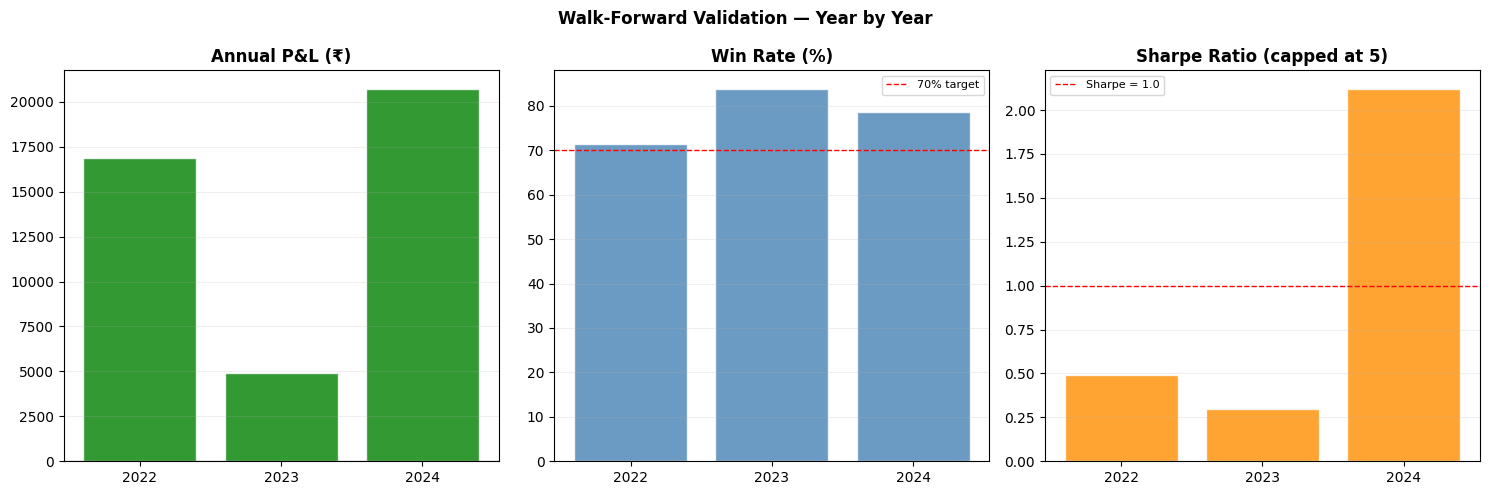

In [51]:
wf_results  = []
wf_yearly   = {}   # store per-year results for the chart

print("═" * 65)
print("  WALK-FORWARD VALIDATION (DEFINITIVE)")
print("═" * 65)

for test_start_year in range(2021, 2025):

    train_end = pd.Timestamp(f"{test_start_year}-01-01")
    test_end  = pd.Timestamp(f"{test_start_year + 1}-01-01")

    train_mask = features.index < train_end
    test_mask  = (features.index >= train_end) & (features.index < test_end)

    if train_mask.sum() < 50 or test_mask.sum() < 10:
        print(f"  {test_start_year}  SKIPPED (train={train_mask.sum()}, "
              f"test={test_mask.sum()})")
        continue

    # ── Fit scaler + HMM fresh for this year ──────────────────────
    sc_yr   = StandardScaler()
    Xtr_s   = sc_yr.fit_transform(features.loc[train_mask, HMM_FEATURES])
    Xte_s   = sc_yr.transform(features.loc[test_mask,  HMM_FEATURES])

    hmm_yr  = GaussianHMM(n_components=3, covariance_type="full",
                           n_iter=2000, random_state=42)
    hmm_yr.fit(Xtr_s)

    # ── Decode and relabel ─────────────────────────────────────────
    raw_regimes = hmm_yr.predict(Xte_s)
    test_dates  = features.index[test_mask]

    vix_by_s  = {}
    for s in range(3):
        mask_s = raw_regimes == s
        if mask_s.sum() == 0:
            vix_by_s[s] = 0
        else:
            vix_by_s[s] = features.loc[test_dates[mask_s], "vix_level"].median()

    sorted_s   = sorted(vix_by_s, key=vix_by_s.get)
    smap_yr    = {sorted_s[0]: 0, sorted_s[1]: 1, sorted_s[2]: 2}

    test_regime_yr = pd.Series(
        [smap_yr[r] for r in raw_regimes],
        index=test_dates
    )

    print(f"\n  {test_start_year} regime distribution:")
    for r, lbl in REGIME_LABELS.items():
        n = (test_regime_yr == r).sum()
        print(f"    {lbl:10s}: {n:3d} days  "
              f"(VIX med={vix_by_s[sorted_s[r]]:.1f})")

    # ── Weekly entry dates via ISO week grouping ───────────────────
    price_in_year = price_series.loc[
        (price_series.index >= train_end) &
        (price_series.index < test_end)
    ]

    iso_week = price_in_year.index.to_series().apply(
        lambda d: f"{d.isocalendar()[0]}-W{d.isocalendar()[1]:02d}"
    )
    entry_dates_yr = price_in_year.groupby(iso_week).apply(
        lambda x: x.index[0]
    )

    print(f"  Weekly entries available: {len(entry_dates_yr)}")

    # ── Simulate trades ────────────────────────────────────────────
    period_pnl  = []
    period_meta = []

    for week_key, entry_date in entry_dates_yr.items():

        # Match regime — use exact date if available, else nearest prior
        if entry_date in test_regime_yr.index:
            regime_date = entry_date
        else:
            prior = test_regime_yr.index[test_regime_yr.index < entry_date]
            if len(prior) == 0:
                continue
            regime_date = prior[-1]
            if (entry_date - regime_date).days > 3:
                continue

        regime = test_regime_yr.loc[regime_date]
        ivp    = features.loc[regime_date, "iv_premium"]
        vix    = features.loc[regime_date, "vix_level"]
        sig    = get_signal(regime, ivp, vix)

        if not sig["enter"]:
            continue

        # Gap filter
        week_prices = price_series.loc[
            entry_date : entry_date + pd.Timedelta(days=6)
        ]
        if len(week_prices) < 2:
            continue

        S_entry  = week_prices.iloc[0]
        prev_idx = price_series.index[price_series.index < entry_date]
        if len(prev_idx) == 0:
            continue
        gap = abs(S_entry / price_series.loc[prev_idx[-1]] - 1)
        if gap > MAX_SPOT_MOVE:
            continue

        # Pricing
        sigma = vix / 100
        size  = sig["size_mult"]

        if sig["strategy"] == "short_straddle":
            K_call = K_put = round(S_entry / 50) * 50
        else:
            K_call = round(S_entry * 1.02 / 50) * 50
            K_put  = round(S_entry * 0.98 / 50) * 50

        T_entry = 4 / 252
        premium = (
            bs_price(S_entry, K_call, T_entry, RISK_FREE, sigma, "call") +
            bs_price(S_entry, K_put,  T_entry, RISK_FREE, sigma, "put")
        ) * size
        stop    = premium * STOP_LOSS_MULT

        # Intraweek stop
        S_exit = week_prices.iloc[min(4, len(week_prices)-1)]
        cost   = (
            bs_price(S_exit, K_call, 0.5/252, RISK_FREE, sigma, "call") +
            bs_price(S_exit, K_put,  0.5/252, RISK_FREE, sigma, "put")
        ) * size

        for j, dp in enumerate(week_prices.iloc[1:], start=1):
            T_rem = max(0.5/252, (4-j)/252)
            c_now = bs_price(dp, K_call, T_rem, RISK_FREE, sigma, "call")
            p_now = bs_price(dp, K_put,  T_rem, RISK_FREE, sigma, "put")
            if ((c_now + p_now) * size - premium) >= stop:
                cost = (c_now + p_now) * size
                break

        pnl = (premium - cost) * NIFTY_LOT_SIZE
        period_pnl.append(pnl)
        period_meta.append({
            "entry_date": entry_date,
            "strategy"  : sig["strategy"],
            "regime"    : REGIME_LABELS[regime],
            "pnl"       : round(pnl, 0)
        })

    if not period_pnl:
        print(f"  {test_start_year}  → NO TRADES AFTER FILTERS")
        continue

    period_pnl = np.array(period_pnl)
    wr  = (period_pnl > 0).mean() * 100
    tot = period_pnl.sum()
    pos = period_pnl[period_pnl > 0].sum()
    neg = abs(period_pnl[period_pnl < 0].sum())
    pf  = pos / neg if neg > 0 else np.inf
    sr  = (period_pnl.mean() / (period_pnl.std() + 1e-10)) * np.sqrt(52)

    result = {
        "test_year": test_start_year,
        "trades"   : len(period_pnl),
        "win_rate" : round(wr, 1),
        "total_pnl": round(tot, 0),
        "avg_pnl"  : round(period_pnl.mean(), 0),
        "pf"       : round(min(pf, 99.0), 2),
        "sharpe"   : round(sr, 2)
    }
    wf_results.append(result)
    wf_yearly[test_start_year] = pd.DataFrame(period_meta)

    print(f"  → trades={len(period_pnl):>3}  "
          f"WR={wr:.1f}%  "
          f"PF={min(pf,99):.2f}  "
          f"P&L=₹{tot:>9,.0f}  "
          f"Sharpe={sr:.2f}")

# ── Summary ────────────────────────────────────────────────────────
wf_df   = pd.DataFrame(wf_results)
real_pf = wf_df[wf_df["pf"] < 99]["pf"]

print("\n" + "═" * 65)
print(f"  Years tested      : {len(wf_df)}")
print(f"  Years profitable  : {(wf_df['total_pnl'] > 0).sum()} / {len(wf_df)}")
print(f"  Avg annual P&L    : ₹{wf_df['total_pnl'].mean():,.0f}")
print(f"  Avg win rate      : {wf_df['win_rate'].mean():.1f}%")
print(f"  Avg Sharpe        : {wf_df[wf_df['sharpe'] < 10]['sharpe'].mean():.2f}")
print(f"  Avg profit factor : {real_pf.mean():.2f}")
print(f"  Worst year P&L    : ₹{wf_df['total_pnl'].min():,.0f}")
print(f"  Best year P&L     : ₹{wf_df['total_pnl'].max():,.0f}")
print("═" * 65)

# ── Final chart ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
years_str = wf_df["test_year"].astype(str)
bar_colors = ["green" if p > 0 else "red" for p in wf_df["total_pnl"]]

axes[0].bar(years_str, wf_df["total_pnl"], color=bar_colors,
            alpha=0.8, edgecolor="white")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Annual P&L (₹)", fontweight="bold")
axes[0].grid(alpha=0.2, axis="y")

axes[1].bar(years_str, wf_df["win_rate"], color="steelblue",
            alpha=0.8, edgecolor="white")
axes[1].axhline(70, color="red", linestyle="--", linewidth=1,
                label="70% target")
axes[1].set_title("Win Rate (%)", fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2, axis="y")

sharpe_plot = wf_df["sharpe"].clip(upper=5)
axes[2].bar(years_str, sharpe_plot, color="darkorange",
            alpha=0.8, edgecolor="white")
axes[2].axhline(1.0, color="red", linestyle="--", linewidth=1,
                label="Sharpe = 1.0")
axes[2].set_title("Sharpe Ratio (capped at 5)", fontweight="bold")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.2, axis="y")

plt.suptitle("Walk-Forward Validation — Year by Year",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

═════════════════════════════════════════════════════════════════
  WALK-FORWARD VALIDATION (ABSOLUTE VIX LABELS)
═════════════════════════════════════════════════════════════════

  2021 regime distribution:
    Low Vol   :   3 days (1%)  raw VIX medians: ['15.1']
    High Vol  : 235 days (99%)  raw VIX medians: ['17.3']
    Crisis    :   0 days (0%)  raw VIX medians: []
  → trades= 40  WR=85.0%  PF=4.47  P&L=₹   66,835  Sharpe=4.40

  2022 regime distribution:
    Low Vol   :   0 days (0%)  raw VIX medians: []
    High Vol  : 241 days (98%)  raw VIX medians: ['18.4', '19.0']
    Crisis    :   6 days (2%)  raw VIX medians: ['28.4']
  → trades= 38  WR=76.3%  PF=1.30  P&L=₹   19,282  Sharpe=0.67

  2023 regime distribution:
    Low Vol   : 245 days (100%)  raw VIX medians: ['11.7', '13.7']
    High Vol  :   0 days (0%)  raw VIX medians: []
    Crisis    :   0 days (0%)  raw VIX medians: []
  → trades= 42  WR=69.0%  PF=1.56  P&L=₹   77,838  Sharpe=1.24

  2024 regime distribution:
    Lo

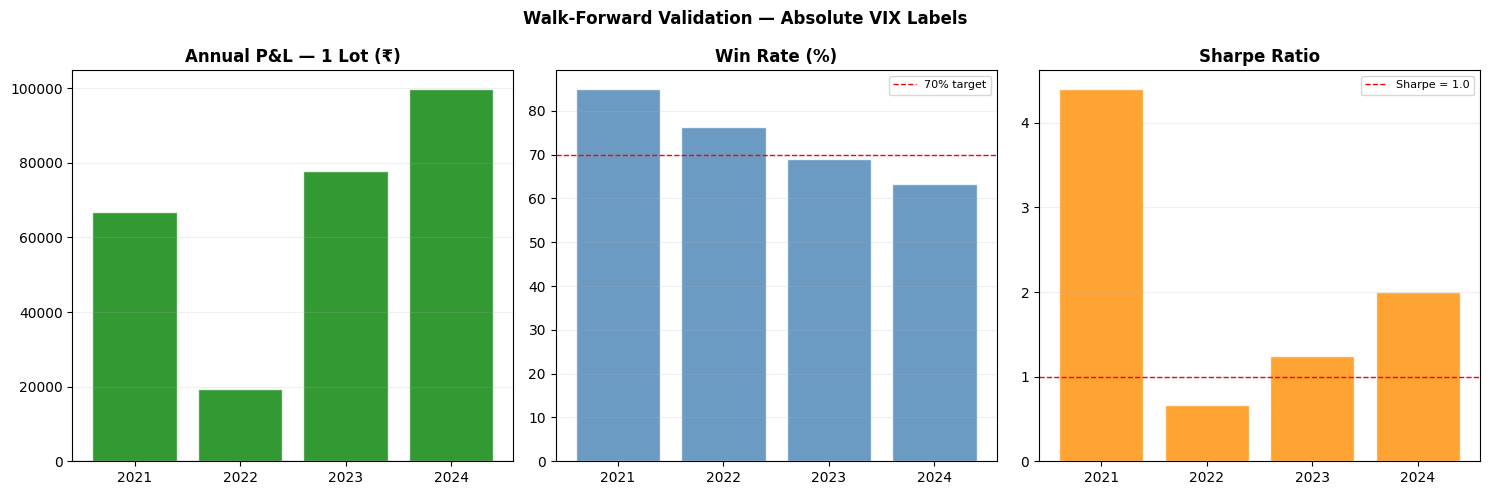

In [52]:
def label_states_absolute(hmm_model, test_features, feature_df, vix_col="vix_level"):
    """
    Label HMM states using absolute VIX thresholds
    rather than relative rank — robust to state collapse.

    Returns: pd.Series of regime labels (0/1/2)
    """
    raw     = hmm_model.predict(test_features)
    dates   = feature_df.index

    # Compute median VIX per state
    vix_by_s = {}
    for s in range(hmm_model.n_components):
        mask = raw == s
        if mask.sum() == 0:
            vix_by_s[s] = -1   # empty state
        else:
            vix_by_s[s] = feature_df.loc[dates[mask], vix_col].median()

    # Absolute thresholds — calibrated to India VIX
    LOW_VOL_MAX  = 17.0
    HIGH_VOL_MAX = 25.0

    smap = {}
    for s, vix_med in vix_by_s.items():
        if vix_med < 0:
            smap[s] = 1            # empty → treat as High Vol (neutral)
        elif vix_med <= LOW_VOL_MAX:
            smap[s] = 0            # Low Vol
        elif vix_med <= HIGH_VOL_MAX:
            smap[s] = 1            # High Vol
        else:
            smap[s] = 2            # Crisis

    return pd.Series([smap[r] for r in raw], index=dates), vix_by_s, smap


# ── Re-run walk-forward with fixed labelling ──────────────────────
wf_results = []
wf_yearly  = {}

print("═" * 65)
print("  WALK-FORWARD VALIDATION (ABSOLUTE VIX LABELS)")
print("═" * 65)

for test_start_year in range(2021, 2025):

    train_end  = pd.Timestamp(f"{test_start_year}-01-01")
    test_end   = pd.Timestamp(f"{test_start_year + 1}-01-01")

    train_mask = features.index < train_end
    test_mask  = (features.index >= train_end) & (features.index < test_end)

    if train_mask.sum() < 50 or test_mask.sum() < 10:
        print(f"  {test_start_year}  SKIPPED")
        continue

    sc_yr  = StandardScaler()
    Xtr_s  = sc_yr.fit_transform(features.loc[train_mask, HMM_FEATURES])
    Xte_s  = sc_yr.transform(features.loc[test_mask,  HMM_FEATURES])

    hmm_yr = GaussianHMM(n_components=3, covariance_type="full",
                          n_iter=2000, random_state=42)
    hmm_yr.fit(Xtr_s)

    # ── Fixed labelling ────────────────────────────────────────────
    test_regime_yr, vix_by_s, smap_yr = label_states_absolute(
        hmm_yr, Xte_s, features.loc[test_mask]
    )

    print(f"\n  {test_start_year} regime distribution:")
    for r, lbl in REGIME_LABELS.items():
        n       = (test_regime_yr == r).sum()
        pct     = n / len(test_regime_yr) * 100
        raw_vix = [f"{vix_by_s[s]:.1f}" for s, mapped in smap_yr.items()
                   if mapped == r and vix_by_s[s] > 0]
        print(f"    {lbl:10s}: {n:3d} days ({pct:.0f}%)  "
              f"raw VIX medians: {raw_vix}")

    # ── Weekly entries ─────────────────────────────────────────────
    price_in_year = price_series.loc[
        (price_series.index >= train_end) &
        (price_series.index < test_end)
    ]
    iso_week      = price_in_year.index.to_series().apply(
        lambda d: f"{d.isocalendar()[0]}-W{d.isocalendar()[1]:02d}"
    )
    entry_dates_yr = price_in_year.groupby(iso_week).apply(
        lambda x: x.index[0]
    )

    # ── Simulate trades ────────────────────────────────────────────
    period_pnl  = []
    period_meta = []

    for week_key, entry_date in entry_dates_yr.items():

        if entry_date in test_regime_yr.index:
            regime_date = entry_date
        else:
            prior = test_regime_yr.index[test_regime_yr.index < entry_date]
            if len(prior) == 0:
                continue
            regime_date = prior[-1]
            if (entry_date - regime_date).days > 3:
                continue

        regime = test_regime_yr.loc[regime_date]
        ivp    = features.loc[regime_date, "iv_premium"]
        vix    = features.loc[regime_date, "vix_level"]
        sig    = get_signal(regime, ivp, vix)

        if not sig["enter"]:
            continue

        week_prices = price_series.loc[
            entry_date : entry_date + pd.Timedelta(days=6)
        ]
        if len(week_prices) < 2:
            continue

        S_entry  = week_prices.iloc[0]
        prev_idx = price_series.index[price_series.index < entry_date]
        if len(prev_idx) == 0:
            continue
        gap = abs(S_entry / price_series.loc[prev_idx[-1]] - 1)
        if gap > MAX_SPOT_MOVE:
            continue

        sigma   = vix / 100
        size    = sig["size_mult"]

        if sig["strategy"] == "short_straddle":
            K_call = K_put = round(S_entry / 50) * 50
        else:
            K_call = round(S_entry * 1.02 / 50) * 50
            K_put  = round(S_entry * 0.98 / 50) * 50

        T_entry = 4 / 252
        premium = (
            bs_price(S_entry, K_call, T_entry, RISK_FREE, sigma, "call") +
            bs_price(S_entry, K_put,  T_entry, RISK_FREE, sigma, "put")
        ) * size
        stop    = premium * STOP_LOSS_MULT

        S_exit  = week_prices.iloc[min(4, len(week_prices)-1)]
        cost    = (
            bs_price(S_exit, K_call, 0.5/252, RISK_FREE, sigma, "call") +
            bs_price(S_exit, K_put,  0.5/252, RISK_FREE, sigma, "put")
        ) * size

        for j, dp in enumerate(week_prices.iloc[1:], start=1):
            T_rem = max(0.5/252, (4-j)/252)
            c_now = bs_price(dp, K_call, T_rem, RISK_FREE, sigma, "call")
            p_now = bs_price(dp, K_put,  T_rem, RISK_FREE, sigma, "put")
            if ((c_now + p_now) * size - premium) >= stop:
                cost = (c_now + p_now) * size
                break

        pnl = (premium - cost) * NIFTY_LOT_SIZE
        period_pnl.append(pnl)
        period_meta.append({
            "entry_date": entry_date,
            "strategy"  : sig["strategy"],
            "regime"    : REGIME_LABELS[regime],
            "pnl"       : round(pnl, 0)
        })

    if not period_pnl:
        print(f"  → NO TRADES AFTER FILTERS")
        continue

    period_pnl = np.array(period_pnl)
    wr  = (period_pnl > 0).mean() * 100
    tot = period_pnl.sum()
    pos = period_pnl[period_pnl > 0].sum()
    neg = abs(period_pnl[period_pnl < 0].sum())
    pf  = pos / neg if neg > 0 else np.inf
    sr  = (period_pnl.mean() / (period_pnl.std() + 1e-10)) * np.sqrt(52)

    result = {
        "test_year": test_start_year,
        "trades"   : len(period_pnl),
        "win_rate" : round(wr, 1),
        "total_pnl": round(tot, 0),
        "avg_pnl"  : round(period_pnl.mean(), 0),
        "pf"       : round(min(pf, 99.0), 2),
        "sharpe"   : round(sr, 2)
    }
    wf_results.append(result)
    wf_yearly[test_start_year] = pd.DataFrame(period_meta)

    print(f"  → trades={len(period_pnl):>3}  "
          f"WR={wr:.1f}%  "
          f"PF={min(pf,99):.2f}  "
          f"P&L=₹{tot:>9,.0f}  "
          f"Sharpe={sr:.2f}")

# ── Summary ────────────────────────────────────────────────────────
wf_df   = pd.DataFrame(wf_results)
real_pf = wf_df[wf_df["pf"] < 99]["pf"]

print("\n" + "═" * 65)
print(f"  Years tested      : {len(wf_df)}")
print(f"  Years profitable  : {(wf_df['total_pnl'] > 0).sum()} / {len(wf_df)}")
print(f"  Avg annual P&L    : ₹{wf_df['total_pnl'].mean():,.0f}")
print(f"  Avg win rate      : {wf_df['win_rate'].mean():.1f}%")
print(f"  Avg Sharpe        : {wf_df[wf_df['sharpe'] < 10]['sharpe'].mean():.2f}")
print(f"  Avg profit factor : {real_pf.mean():.2f}")
print(f"  Worst year P&L    : ₹{wf_df['total_pnl'].min():,.0f}")
print(f"  Best year P&L     : ₹{wf_df['total_pnl'].max():,.0f}")
print("═" * 65)

# ── Chart ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
years_str  = wf_df["test_year"].astype(str)
bar_colors = ["green" if p > 0 else "red" for p in wf_df["total_pnl"]]

axes[0].bar(years_str, wf_df["total_pnl"], color=bar_colors,
            alpha=0.8, edgecolor="white")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Annual P&L — 1 Lot (₹)", fontweight="bold")
axes[0].grid(alpha=0.2, axis="y")

axes[1].bar(years_str, wf_df["win_rate"], color="steelblue",
            alpha=0.8, edgecolor="white")
axes[1].axhline(70, color="red", linestyle="--",
                linewidth=1, label="70% target")
axes[1].set_title("Win Rate (%)", fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.2, axis="y")

sharpe_plot = wf_df["sharpe"].clip(upper=5)
axes[2].bar(years_str, sharpe_plot, color="darkorange",
            alpha=0.8, edgecolor="white")
axes[2].axhline(1.0, color="red", linestyle="--",
                linewidth=1, label="Sharpe = 1.0")
axes[2].set_title("Sharpe Ratio", fontweight="bold")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.2, axis="y")

plt.suptitle("Walk-Forward Validation — Absolute VIX Labels",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()